# Analyze and plot results for networks performance

This script takes in the results from data-overview.ipynb and fit-observables.ipynb, and performs analyses on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
import seaborn as sns

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

## 0. Load data and build datasets

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-vary_b_I"

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

full_sim_data = pd.read_pickle(d_mean)
# with pd.option_context('display.max_columns', None):
#     display(use_sim_data)

## 1. Performance-based evaluation of immune networks

In [3]:
# Create additional variables
module_reg = {'$N \longrightarrow N^*$': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              '$N^* \longrightarrow E$': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              '$E \longrightarrow \emptyset$': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}
module_reg_labels = {'$N \longrightarrow N^*$': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['$N \longrightarrow N^*$']], 
                     '$N^* \longrightarrow E$': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['$N^* \longrightarrow E$']],
                     '$E \longrightarrow \emptyset$': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['$E \longrightarrow \emptyset$']]}

signal_classes = [r for i, r in enumerate(["Ag. sens.", "Inflam. sens.", "Anti-inflam. sens.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]
stim_vars = ['stim_pI', 'stim_pHI', 'stim_pHE']

# if "full" in comment or "sparse" in comment:
reg = [r for r in Na_reg + NE_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
reg_label = param_names[-16:-12] + param_names[-12:-8] + param_names[-4:]
module_labels = ['$N \longrightarrow N^*$', '$N^* \longrightarrow E$', '$E \longrightarrow \emptyset$']

opt_vars = ['psi_I', 'psi_HI', 'psi_HE', 'g0_Na', 'g0_NE', 'g0_Edie'] #, reg_bl[2]]
opt_vars_labels = [r"$\psi_{E}^{Ag}$",
                   r"$\psi_{E}^{H_I}$",
                   r"$\psi_{E}^{H_E}$",
                   r"$g_{0,N \to N^*}, g_{0,E \to 2E}$",
                   r"$g_{0,N^* \to E}$",
                   r"$g_{0,E \to \emptyset}$"]

num_categories = len(perf_labels)
reg_markers = ['o', 's', 'v', '^', 'X','*', 'D','>', '<']
num_modules = len(module_labels)
num_psis = len(Na_reg)

cmap_colors = sns.color_palette("Set2") #['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
perf_var_colors = ['green', 'black', 'red']
intercept_vars = ['intercept_Na', 'intercept_NE', 'intercept_EE']

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# helper variables
n_virs = len(infection_scenarios)
del infection_scenarios

### (a) Dependence of performance on individual signals

In [4]:
keep_vars = opt_vars + perf_vars + vir_vars + reg_bl + ['frac_cM', 'max_pE','T_pE_start', 'T_pE_max', 'T_pE_end','stim_pI', 'stim_pHI', 'stim_pHE','E_end', 'R_0', 'feedback']
use_sim_data = full_sim_data.loc[full_sim_data.K_H == K_H].copy()
use_sim_data.loc[:, 'R_0'] = use_sim_data['S_0']*use_sim_data['b_I']/use_sim_data['d_I'] - 1
use_sim_data.loc[:, opt_vars[0:3]] = use_sim_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
use_sim_data.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-use_sim_data[reg_bl].values))
use_sim_data.loc[:, 'feedback'] = np.round(np.amax(np.abs(use_sim_data[opt_vars[0:3]]), axis = 1), 2)

del full_sim_data

### (c) Performance of the immune response in different contexts

In [5]:
# Visualize optimal regulation
plots = [vir_vars[1], 'R_0']
plot_labels = ["Affinity $\frac{S_{max}}{K_I}$", "Reproduction\n number $R_0$"]
short_plot_labels = [r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", r"$R_0$"]
size = 2500/np.cbrt(n_virs)

import heapq
infections_params = use_sim_data.groupby(vir_vars, as_index = False).mean()

highK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])
midK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])
lowK_I_highR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])

highK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
midK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
lowK_I_midR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])

highK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nlargest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])
midK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])
lowK_I_lowR_0 = (infections_params.K_H == np.amin(infections_params.K_H))*(infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[4])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])

quadrants = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[midK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[midK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0],
                       infections_params.loc[highK_I_lowR_0],
                       infections_params.loc[midK_I_lowR_0],
                       infections_params.loc[lowK_I_lowR_0]
                      ])

quadrants_small = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0]
                      ])


quadrants_labels = x = ['Low ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', slow '+short_plot_labels[1],]

### (d) Dependence of performance on modules and architectures

In [6]:
# Define utility and constraint functions

num_cpu = 100

linestyles = ['-','--','-','-.',':','--', '-.']

def sample_3d_simplex(weights = [1,1,1], pnts = 100):
    """Samples points uniformly from the 3D simplex."""
    x = np.random.dirichlet(weights, pnts)
    
    return x

def grid_search(input, type = "global", vars = perf_vars[0:3], top = 10):

    df_list = []
    input.loc[:,opt_vars[0]] = input['psi_NE_I']
    input.loc[:,opt_vars[1]] = input['psi_NE_HI']
    input.loc[:,opt_vars[2]] = input['psi_NE_HE']
    data = input #.groupby(opt_vars, as_index = False).mean()
    
    if type == "global":
        for i, perf in enumerate(vars):
            data_sorted = data.sort_values(by=perf, ascending= True)
            max_row = data_sorted.head(top).mean()
            # max_row = data.loc[data[perf].idxmax()].copy()
            max_row.loc['perf_index'] = i
            df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index'])

    elif type == "ablate":
        for i, perf in enumerate(vars):
            for j, p in enumerate(opt_vars):
                for (_, g) in data.groupby(p, as_index = False):
                    g_sorted = g.sort_values(by=perf, ascending= True)
                    max_row = g_sorted.head(top).mean()
                    #max_row = data.loc[data.groupby(p)[perf].idxmax()].copy() if i != 2 else data.loc[data.groupby(p)[perf].idxmin()].copy()
                    max_row.loc['perf_index'] = i
                    max_row.loc['ablate_index'] = j
                    df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index', 'ablate_index'])
        
    return out

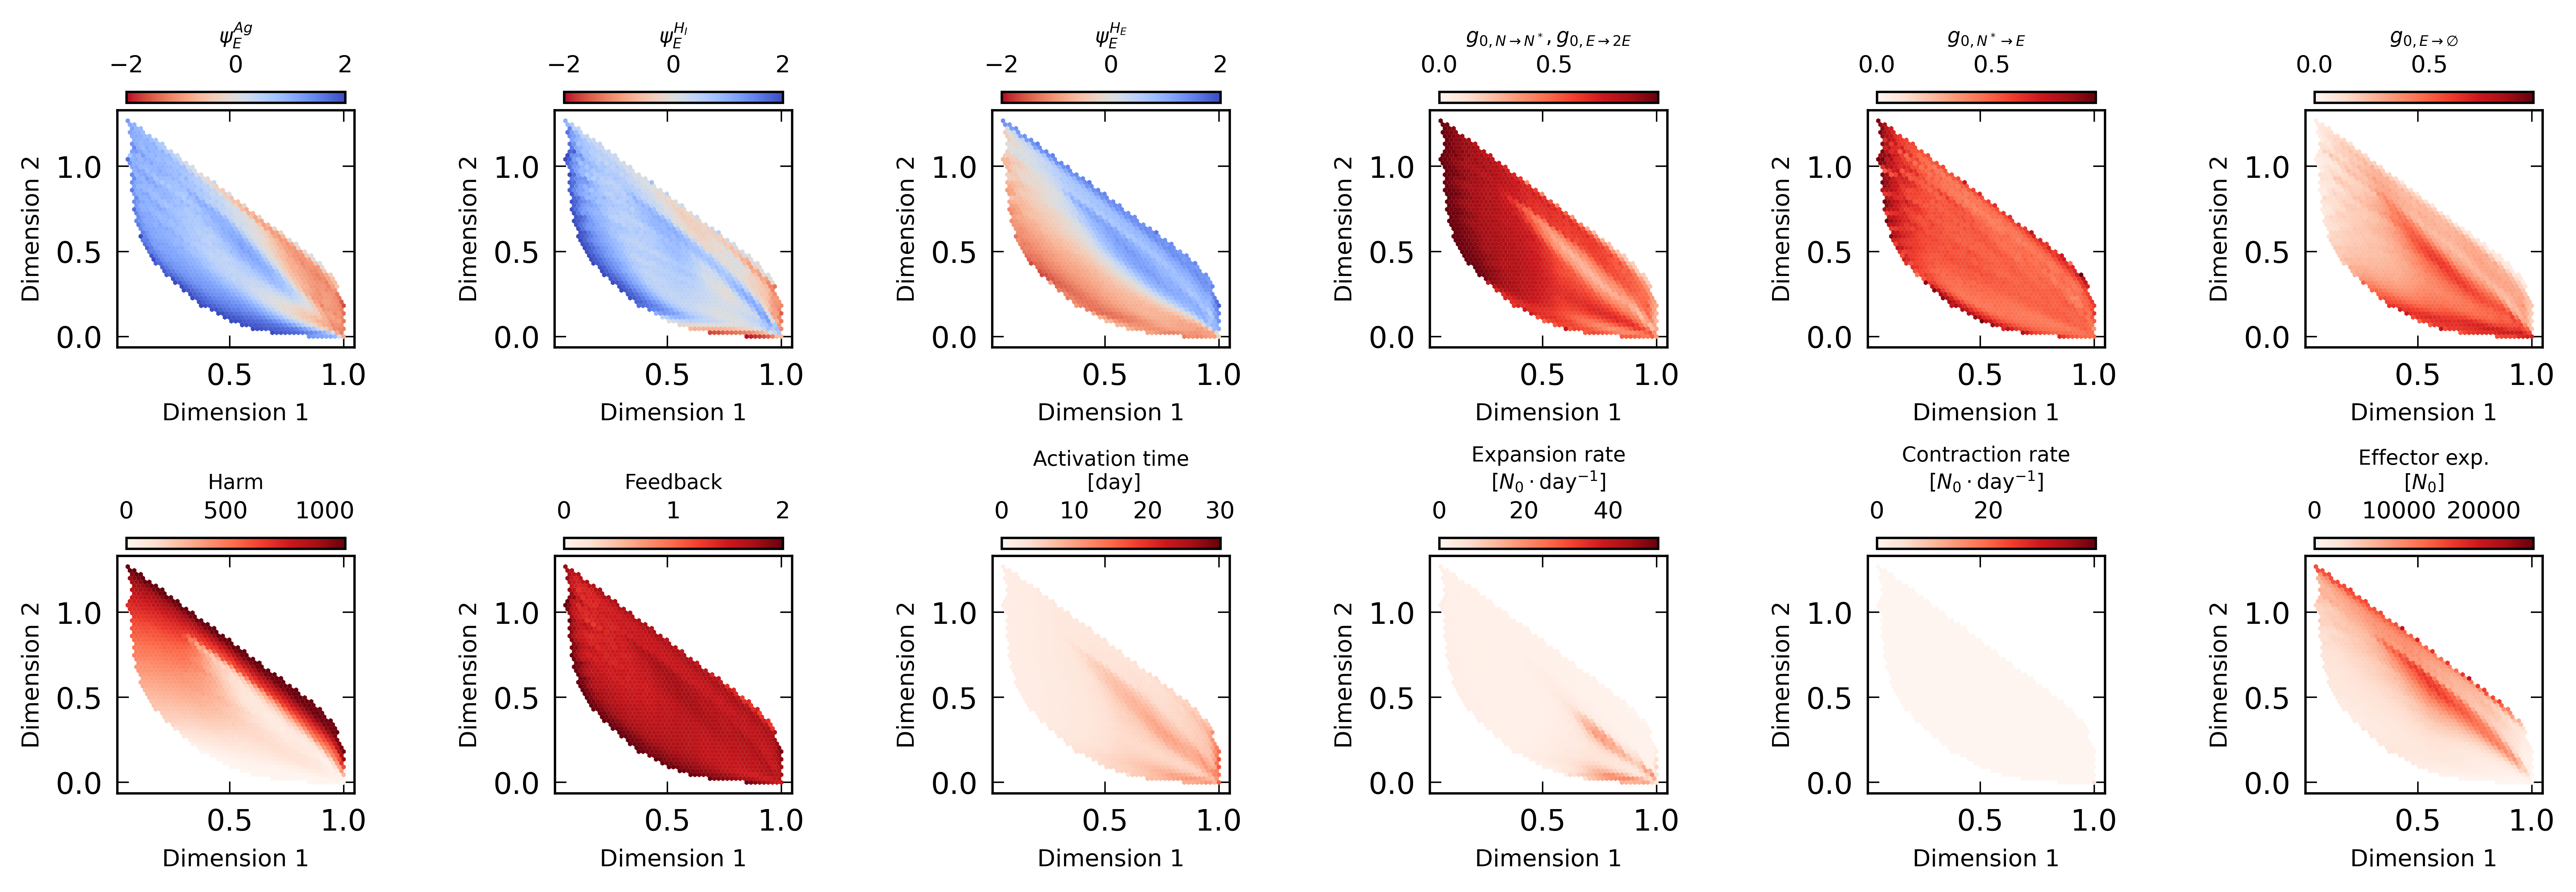

In [7]:
# Create effector trajectory variables
avg_sim_data = use_sim_data.loc[(use_sim_data['b_I'].values > 0.0)*(use_sim_data.d_I > d_S)].groupby(opt_vars, as_index = False).mean()
avg_sim_data.loc[:,'exp_rate'] = np.log(avg_sim_data['max_pE']/max_Na)/np.maximum(avg_sim_data['T_pE_max'] - avg_sim_data['T_pE_start'], t_cycle)
avg_sim_data.loc[:,'end_rate'] = -np.log(avg_sim_data['max_pE']/avg_sim_data['N_0'])/np.maximum(avg_sim_data['T_pE_end'] - avg_sim_data['T_pE_max'], t_cycle)
avg_sim_data.loc[:,'max_exp'] = avg_sim_data['max_pE']/avg_sim_data['N_0']

dyn_vars_for_dim = opt_vars + ['peff_scaled_total_harm', 'feedback', 'T_pE_start', 'exp_rate', 'end_rate', 'max_exp']
dyn_labels_for_dim = opt_vars_labels + ['Harm', 'Feedback'] + ['Activation time\n [day]', 'Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', 'Contraction rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', 'Effector exp.\n'+ r'[$N_0$]']

fig, axs = plt.subplots(2,len(opt_vars), figsize = (15,4.5), dpi=300, sharex = True, sharey = True)

for k, ax in enumerate(axs.flat):
    z = avg_sim_data[dyn_vars_for_dim[k]]
    range = np.amax(np.abs(z))
    im = ax.hexbin(avg_sim_data.peff_infection/avg_sim_data.harm_pI_noprotection, avg_sim_data.peff_toxicity/avg_sim_data.harm_pI_noprotection,
                       gridsize = 50, C = z, linewidths = 0.0,
                   cmap= 'coolwarm_r' if k < 3 else 'Reds',# alpha = 0.8,
                   norm= mpl.colors.Normalize(vmin = -range if k < 3 else 0.0, vmax = range))
                   #norm= mpl.colors.LogNorm() if 'time' in dyn_labels_for_dim[k] else (mpl.colors.Normalize(vmin = -range, vmax = range) if k < 6 else mpl.colors.Normalize()) )

    #ax.set_title(dyn_labels_for_dim[k], fontsize = 7.5)
    ax.set_xlabel('Dimension 1', fontsize = 8)
    ax.set_ylabel('Dimension 2', fontsize = 8)
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.025)
    cb.set_label(dyn_labels_for_dim[k], fontsize = 7)
    cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.6, hspace=0.55)

plt.savefig('_figs/'+comment+'-'+'-reg-average_clear_tox'+'.pdf', dpi=150, format="pdf", transparent=True, bbox_inches="tight")

#### Optimize $[\text{Infection harm}]$

/tmp/ipykernel_10364/3940826433.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
/tmp/ipykernel_10364/3940826433.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
/tmp/ipykernel_10364/3940826433.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

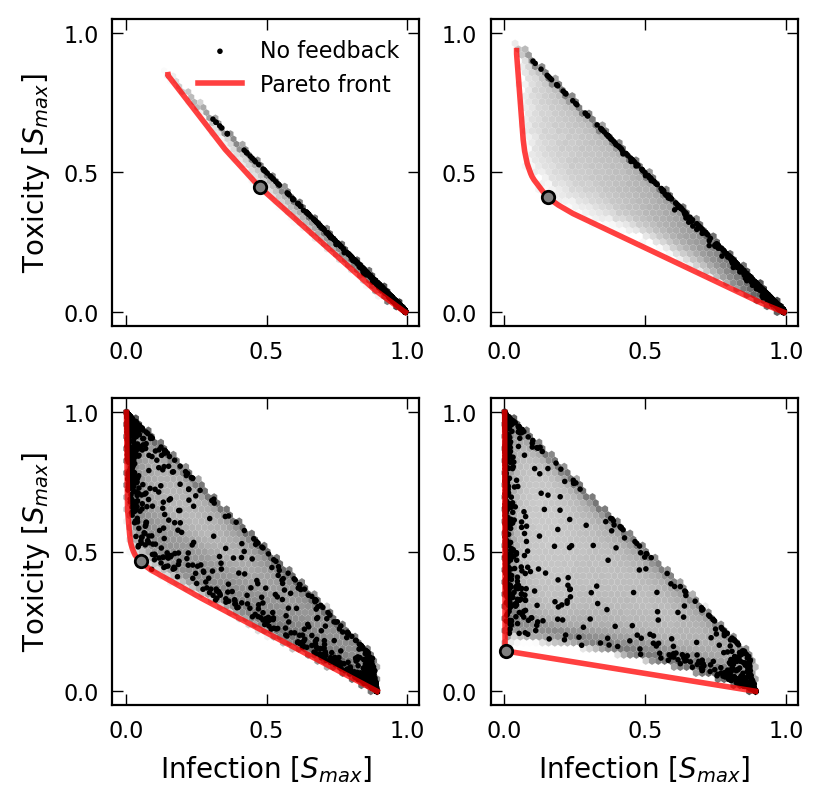

In [9]:
# Visualize pareto regulation
perf_x, perf_y = 1, 2
kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

fig, axs = plt.subplots(2, 2, 
                          figsize=(4, 4), sharex=True, sharey=True, layout='constrained')

lambdas = np.linspace(0,1,21)

for k, a in enumerate(quadrants_small[plots].values):
    data = use_sim_data.loc[(use_sim_data[plots[0]] == a[0])*(use_sim_data[plots[1]] == a[1])]
    
    z_label = r"Scaled Harm"

    y, x = k % 2, k // 2
    
    axs[x,y].hexbin(data.peff_infection, data.peff_toxicity,
                       gridsize = 40, C = None,
                         cmap='Grays', edgecolors = 'None',
                   norm = mpl.colors.LogNorm())
    # axs[x,y].scatter(data.peff_infection, data.peff_toxicity,
    #               s = 2, color = "gray",
    #               label = 'with feedback',
    #               edgecolors = 'None')

    no_fbk = np.sum(np.abs(data[opt_vars[0:3]]), axis = 1) == 0
    axs[x,y].scatter(data.loc[no_fbk].peff_infection, data.loc[no_fbk].peff_toxicity,
                      s = 4, color = "black",
                      label = 'No feedback',
                      edgecolors = 'None')
    pareto_designs = []
    
    for l in lambdas:
        data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
        data_sorted = data.sort_values(by='compromise', ascending= True).copy()
        max_row = data_sorted.head(10).mean()
        pareto_designs.append(max_row.values) # plot_data.loc[pareto_index]
    
    pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())

    axs[x,y].plot(pareto_design_df['peff_infection'].values, 
                  pareto_design_df['peff_toxicity'].values,
                  color='red', linewidth = 2.0, alpha = 0.75,
                  label = 'Pareto front')

    axs[x,y].scatter(pareto_design_df['peff_infection'].values[int(len(lambdas)/2)], 
                     pareto_design_df['peff_toxicity'].values[int(len(lambdas)/2)],
                     s = 20,
                     color='grey', edgecolors = 'black', zorder = 2)
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=8)
    axs[x,y].locator_params(axis='y', nbins=4)
    axs[x,y].locator_params(axis='x', nbins=4)
    

    # if k == 1:
    #     cb = fig.colorbar(im, ax=axs[x,y], location='right', shrink = 0.85, pad = 0.25)
    #     cb.set_label(z_label, fontsize = 10)
    #     cb.ax.tick_params(labelsize=8)
axs[0,0].legend(fontsize=8)
# fig.subplots_adjust(wspace=.4, hspace=0.5)
# cb = fig.colorbar(im, ax=axs.ravel().tolist(), location = 'bottom', pad = 0.125, shrink = 0.7)
# cb.set_label(z_label, fontsize = 10)
# cb.ax.tick_params(labelsize=8)

for j, ax in enumerate(axs.flat):
    if j // 2 == 1:
        ax.set_xlabel(perf_labels[perf_x] + r' [$S_{max}$]', fontsize = 10)
    if j % 2 == 0:
        ax.set_ylabel(perf_labels[perf_y] + r' [$S_{max}$]', fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    #ax.set_title(quadrants_labels[j], fontsize = 8.0, pad = 2.5)

plt.savefig('_figs/fig3_'+comment+'-reg-singles_clear_tox'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

##### Minimize Harm for each infection

In [10]:
# Find optimal designs for each infection by grid searching
grid_opt = pd.concat(Parallel(n_jobs = num_cpu,
                          batch_size = 1)(delayed(grid_search)(g, top = 10)
                                                   for (_, g) in use_sim_data.groupby(vir_vars)
                                                  ))

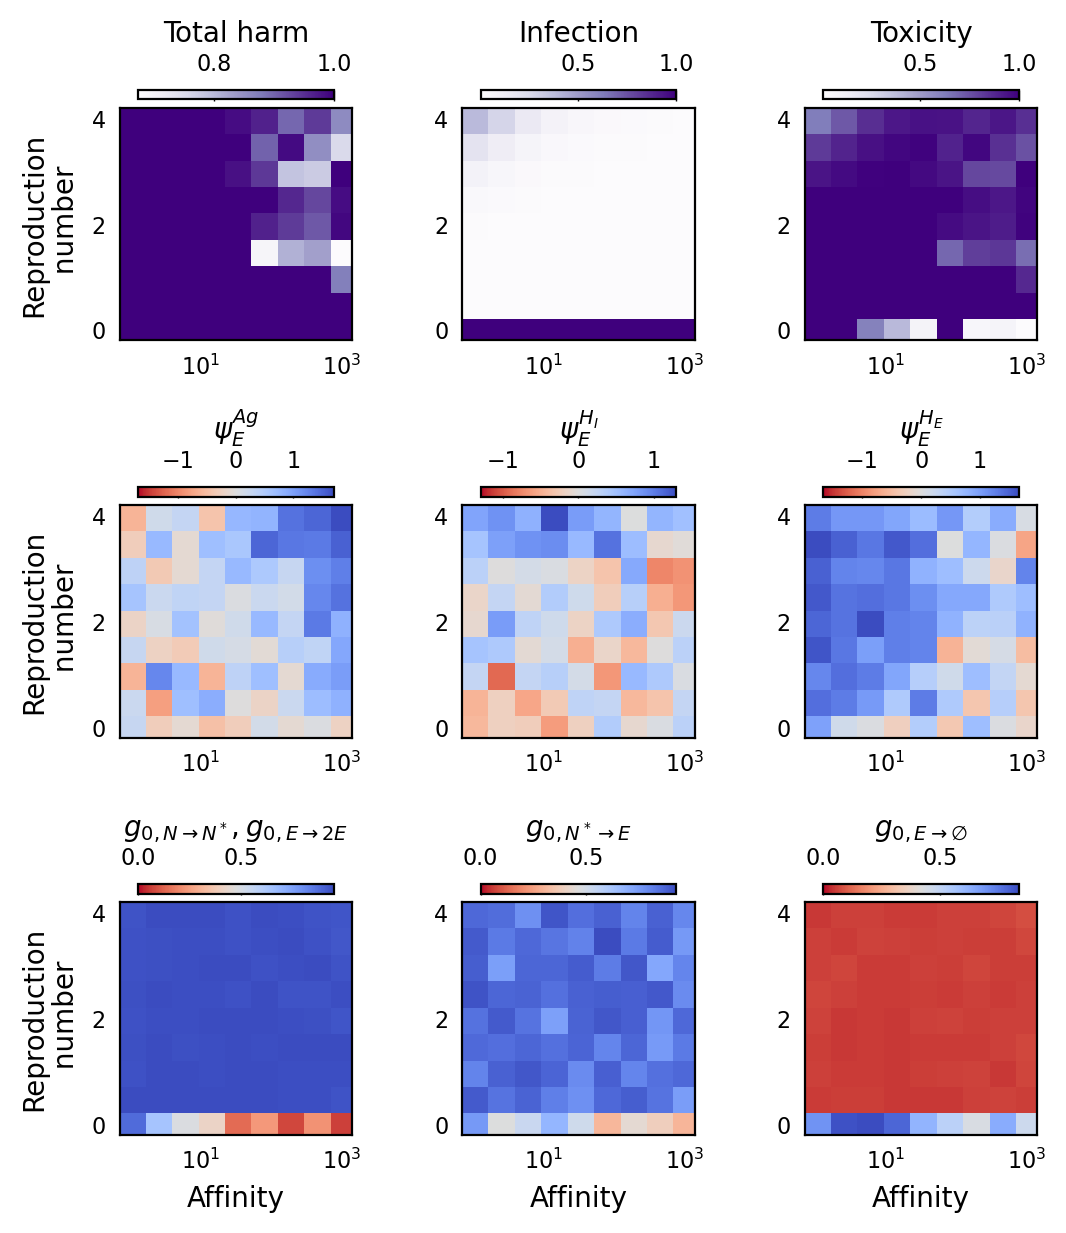

In [11]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 7), sharex=True, sharey=True)

size = 550/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 1)]

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values/data['harm_pI_noprotection'].values if k in [1,2] else data[var].values
    range = np.amax(np.abs(z))

    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='Purples' if k <=2 else 'coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range))

    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    
    z_label = (perf_labels[0:3] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.03)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=0.4, hspace=0.4)

plt.savefig('_figs/figSI_'+comment+'-reg-singles_clearance_feedback_reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300, bbox_inches="tight")

/tmp/ipykernel_10364/1660591372.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_input.loc[:,'log_K_I'] = np.log10(S_0/cluster_input[plots[0]].values)
/tmp/ipykernel_10364/1660591372.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_input.loc[:,'raw_cluster'] = clustering.labels_
/tmp/ipykernel_10364/1660591372.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

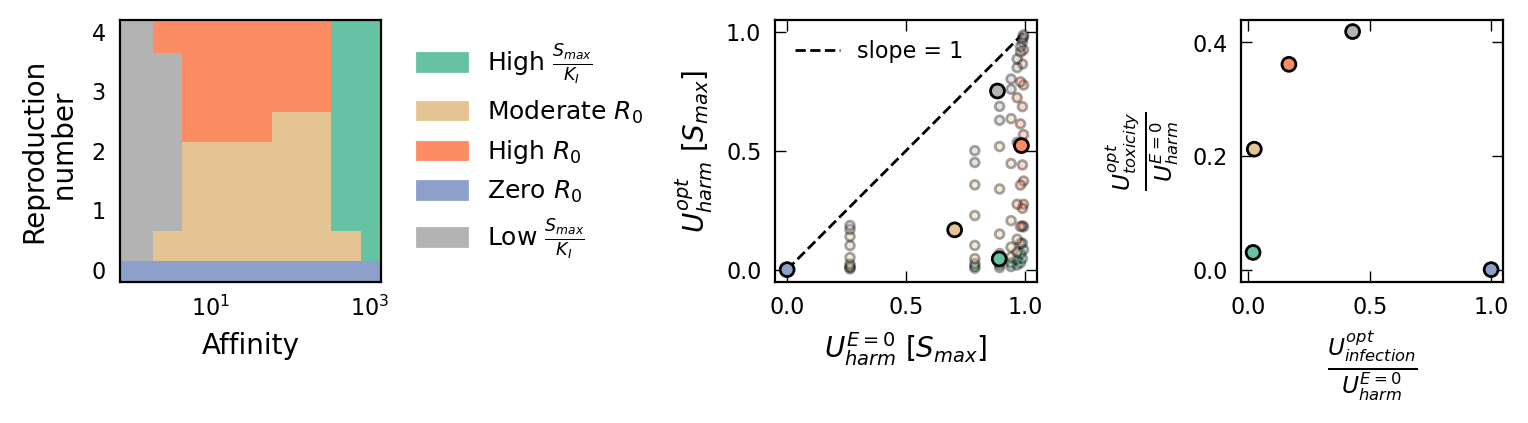

In [94]:
fig, axs = plt.subplots(1, 3, 
                          figsize=(7.75, 2), sharex=False, sharey=False, constrained_layout=True)

size = 1000/np.cbrt(n_virs)
cluster_colors = ['#66c2a5', cmap_colors[-2], '#fc8d62', '#8da0cb', cmap_colors[-1], '#e78ac3', cmap_colors[-3]]

cluster_input = grid_opt.loc[(grid_opt.perf_index == 0)]
cluster_input.loc[:,'log_K_I'] = np.log10(S_0/cluster_input[plots[0]].values)
scaler = StandardScaler()
scaler.fit(cluster_input[opt_vars + ['K_I', plots[1]]].values)
for_clustering = scaler.transform(cluster_input[opt_vars + ['K_I', plots[1]]].values)
clustering = KMeans(n_clusters=5, n_init = 10,
        random_state=0).fit(for_clustering)

cluster_input.loc[:,'raw_cluster'] = clustering.labels_
assign_phase = cluster_input.groupby(['raw_cluster'], 
                                     as_index = False).mean().sort_values(by=plots, 
                                                                          ascending= True).reset_index()[plots + ['raw_cluster']]
cluster_input.loc[:,'phase_cluster'] = np.array([assign_phase.loc[assign_phase.raw_cluster == p].index.tolist()[0] for p in cluster_input.raw_cluster.values]) #clustering.labels_

## Make plots
# (a) Plot infection clusters
axs[0].scatter(S_0/cluster_input[plots[0]], cluster_input[plots[1]],
                 marker ='s', s = size, 
                c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values], 
                 edgecolors = 'None')

axs[0].set_xlabel(plot_labels[0], fontsize = 10)
axs[0].set_ylabel(plot_labels[1], fontsize = 10)
axs[0].semilogx()

legend_handles = []
phase_clusters = np.unique(cluster_input['phase_cluster'].values)
phase_cluster_labels = [r"High $\frac{S_{max}}{K_I}$", r"Moderate $R_0$", r"High $R_0$", r"Zero $R_0$", r"Low $\frac{S_{max}}{K_I}$"]
n_clusters = len(phase_clusters)
for key, color in enumerate([cluster_colors[i] for  i in phase_clusters]):
    patch = mpatches.Patch(color=color, label=str(phase_cluster_labels[key]))
    legend_handles.append(patch)

axs[0].legend(handles=legend_handles, bbox_to_anchor=(1.05, 1.0), fontsize=9, framealpha=0, ncol = 1)

# (b) Plot optimized and unoptimized harm
plot_data = cluster_input.groupby('phase_cluster', as_index = False).mean()

axs[1].scatter(plot_data.harm_pI_noprotection, 
               plot_data.peff_total_harm,
               c = [cluster_colors[i] for i in plot_data.phase_cluster.values],
               s = 25, edgecolors = 'black', zorder = 2)

axs[1].scatter(cluster_input.harm_pI_noprotection, 
               cluster_input.peff_total_harm,
               c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
               s = 10, edgecolors = 'black', zorder = 1, alpha = 0.35)

axs[1].plot(np.linspace(0,1), np.linspace(0,1), color = 'black', linestyle = '--', zorder = 0, label='slope = 1')
axs[1].locator_params(axis='x', nbins=4)
axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(fontsize = 8)
axs[1].set_xlabel(r'$U_{harm}^{E = 0}$ [$S_{max}$]', fontsize = 10)
axs[1].set_ylabel(r'$U_{harm}^{opt}$ [$S_{max}$]', fontsize = 10)

# (c) Plot optimized infection and toxicity
axs[2].scatter(plot_data.peff_infection/plot_data.harm_pI_noprotection, 
               plot_data.peff_toxicity/plot_data.harm_pI_noprotection,
               c = [cluster_colors[i] for i in plot_data.phase_cluster.values],
               s = 25, edgecolors = 'black', zorder = 2)

axs[2].locator_params(axis='x', nbins=4)
axs[2].locator_params(axis='y', nbins=4)

axs[2].set_xlabel(r'$\frac{U_{infection}^{opt}}{U_{harm}^{E = 0}}$', fontsize = 12)
axs[2].set_ylabel(r'$\frac{U_{toxicity}^{opt}}{U_{harm}^{E = 0}}$', fontsize = 12)

for ax in axs.flat:
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=8)

plt.savefig('_figs/fig3_'+comment+'-optimal-reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

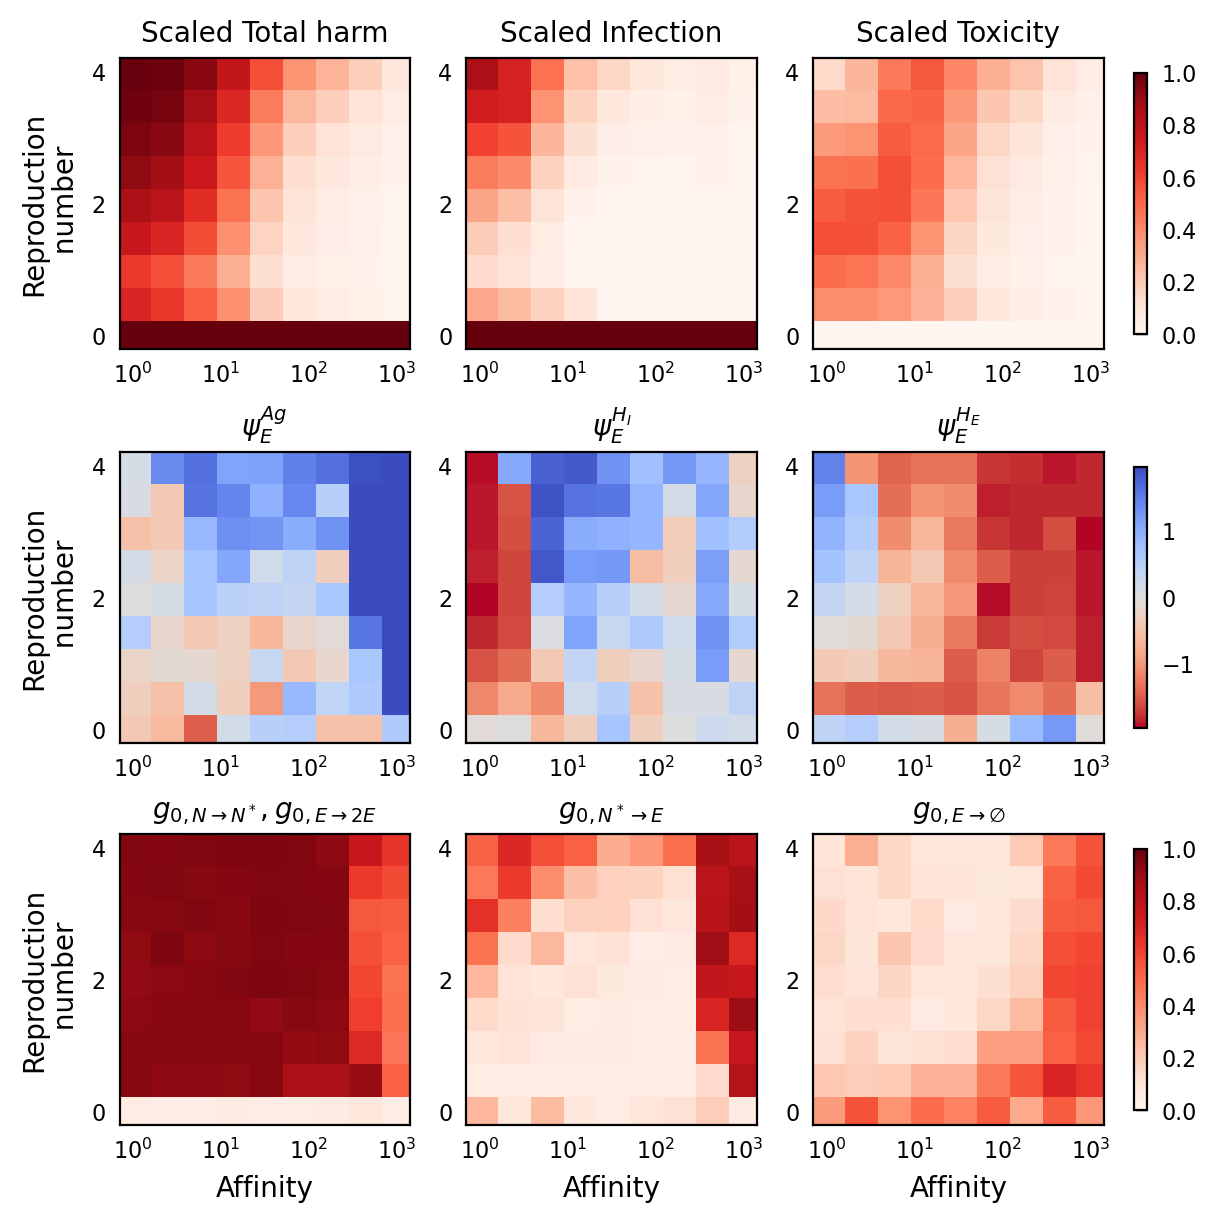

In [17]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 6), sharex=True, sharey=True, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 0)]

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values/data['harm_pI_noprotection'].values if k in [1,2] else data[var].values
    range = np.amax(np.abs(z))

    # ax.tricontour(cluster_input['S_0']/cluster_input[plots[0]], 
    #               1.0*cluster_input[plots[1]], 
    #              cluster_input['phase_cluster'], levels = phase_clusters, linewidths=2.0, colors=cluster_colors)

    # ax.tricontour(S_0/data[plots[0]], data[plots[1]], z, 
    #               linewidths=0.1, colors='k')
    
    # im = ax.tricontourf(S_0/data[plots[0]], data[plots[1]], z, 
    #                     cmap='Purples' if k <=2 else 'coolwarm_r',
    #              norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range if k < 6 else 1.0))

    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap=['Reds','coolwarm_r', 'Reds'][k // 3], edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0.0, vmax = np.amax(data[perf_vars[0]])) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range if k < 6 else 1.0))

    z_label = (['Scaled ' + perf_labels[0], 'Scaled ' + perf_labels[1], 'Scaled ' + perf_labels[2]] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    ax.set_title(z_label, fontsize = 10.0)
    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    
    if k % 3 == 2:
        cb = fig.colorbar(im, ax=axs[k // 3,:], location='right', shrink = 0.9, pad = 0.025)
        # cb.set_label(z_label, fontsize = 10)
        cb.ax.tick_params(labelsize=8)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/figSI_'+comment+'-reg-singles_prot_strong_feedback_reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

The optimal response depends on the Affinity of the pathogens encountered. The optimal design of the response to high Affinity pathogens demonstrates the logic that the system should be tuned to respond to threats that it can easily detect.

In [18]:
# Add cluster information to data
cluster_sim_df = use_sim_data.merge(cluster_input[plots + ['phase_cluster']], how = 'left', on = plots)

# Compute design performance in each cluster
avg_cluster_data = cluster_sim_df.groupby(opt_vars + ['phase_cluster'], as_index = False).mean()

In [19]:
# Compute optimal performance as a function of allowed feedback strength
cluster_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 6)(delayed(grid_search)(g, type = 'global', top = 10)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster'],as_index = False)
                                                  ))

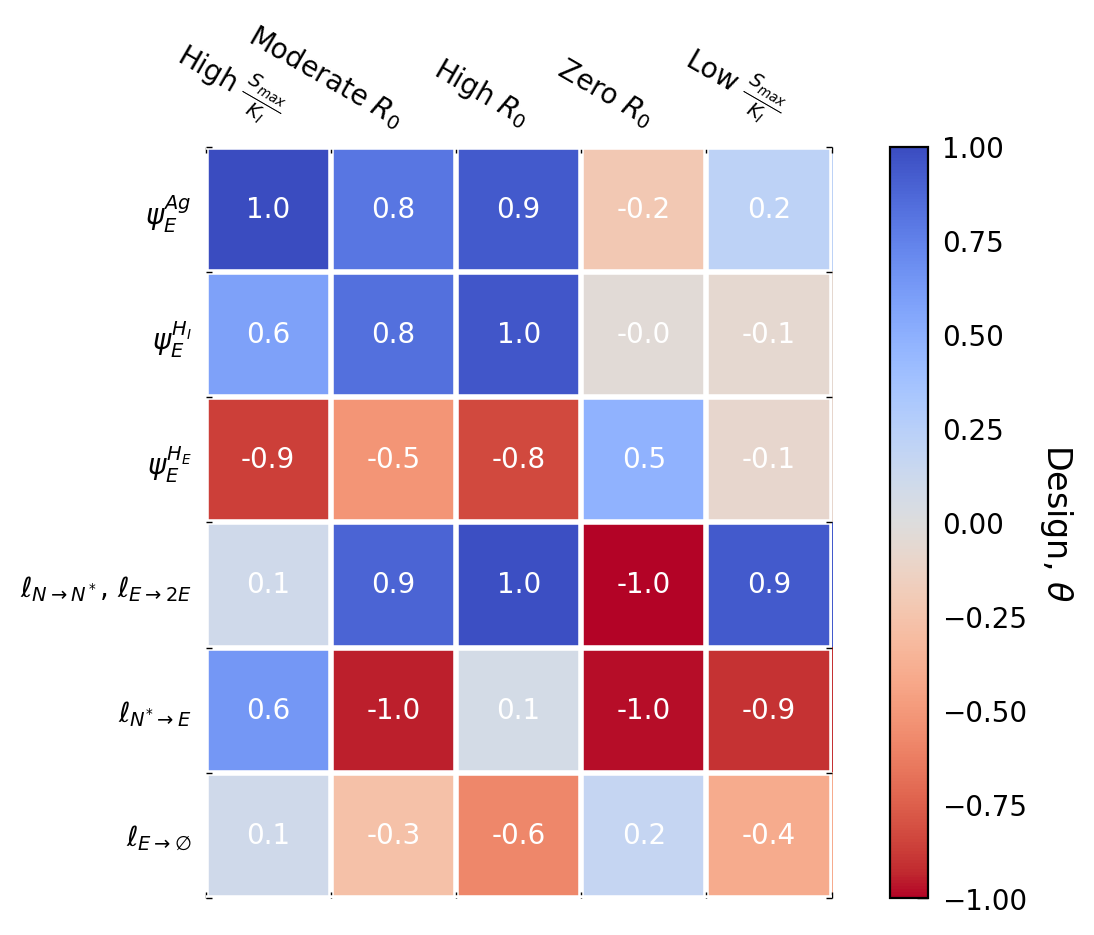

In [49]:
row_labels = opt_vars_labels[0:3] + reg_bl_label
col_labels = phase_cluster_labels #[phase_clusters.tolist()
opt_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0][opt_vars[0:3] + reg_bl].values/np.array(3*[psi_max] + 3*[L0_max])).T

fig, ax = plt.subplots()
im = ax.imshow(opt_reg_data, cmap = 'coolwarm_r')

# Create colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel(r"Design, $\theta$", rotation=-90, va="bottom")

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(col_labels)), labels=col_labels,
              rotation=-30, ha="right", rotation_mode="anchor")
ax.set_yticks(np.arange(len(row_labels)), labels=row_labels)

# Let the horizontal axes labeling appear on top.
ax.tick_params(top=True, bottom=False,
               labeltop=True, labelbottom=False)

# Loop over data dimensions and create text annotations.
for i in np.arange(len(row_labels)):
    for j in np.arange(len(col_labels)):
        text = ax.text(j, i, np.round(opt_reg_data[i, j], 1),
                       ha="center", va="center", color="w")

# Turn spines off and create white grid.
ax.spines[:].set_visible(False)

ax.set_xticks(np.arange(opt_reg_data.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(opt_reg_data.shape[0]+1)-.5, minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
ax.tick_params(which="major", bottom=False, left=False, top = False, right = False)
# #ax.set_title("Optimal feedback designs")
#ax.minorticks_off()

fig.tight_layout()
plt.show()

fig.savefig('_figs/fig3_'+comment+'-reg-cluster_opt-reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=150)

/tmp/ipykernel_10364/3345960344.py:123: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-0.05, None)


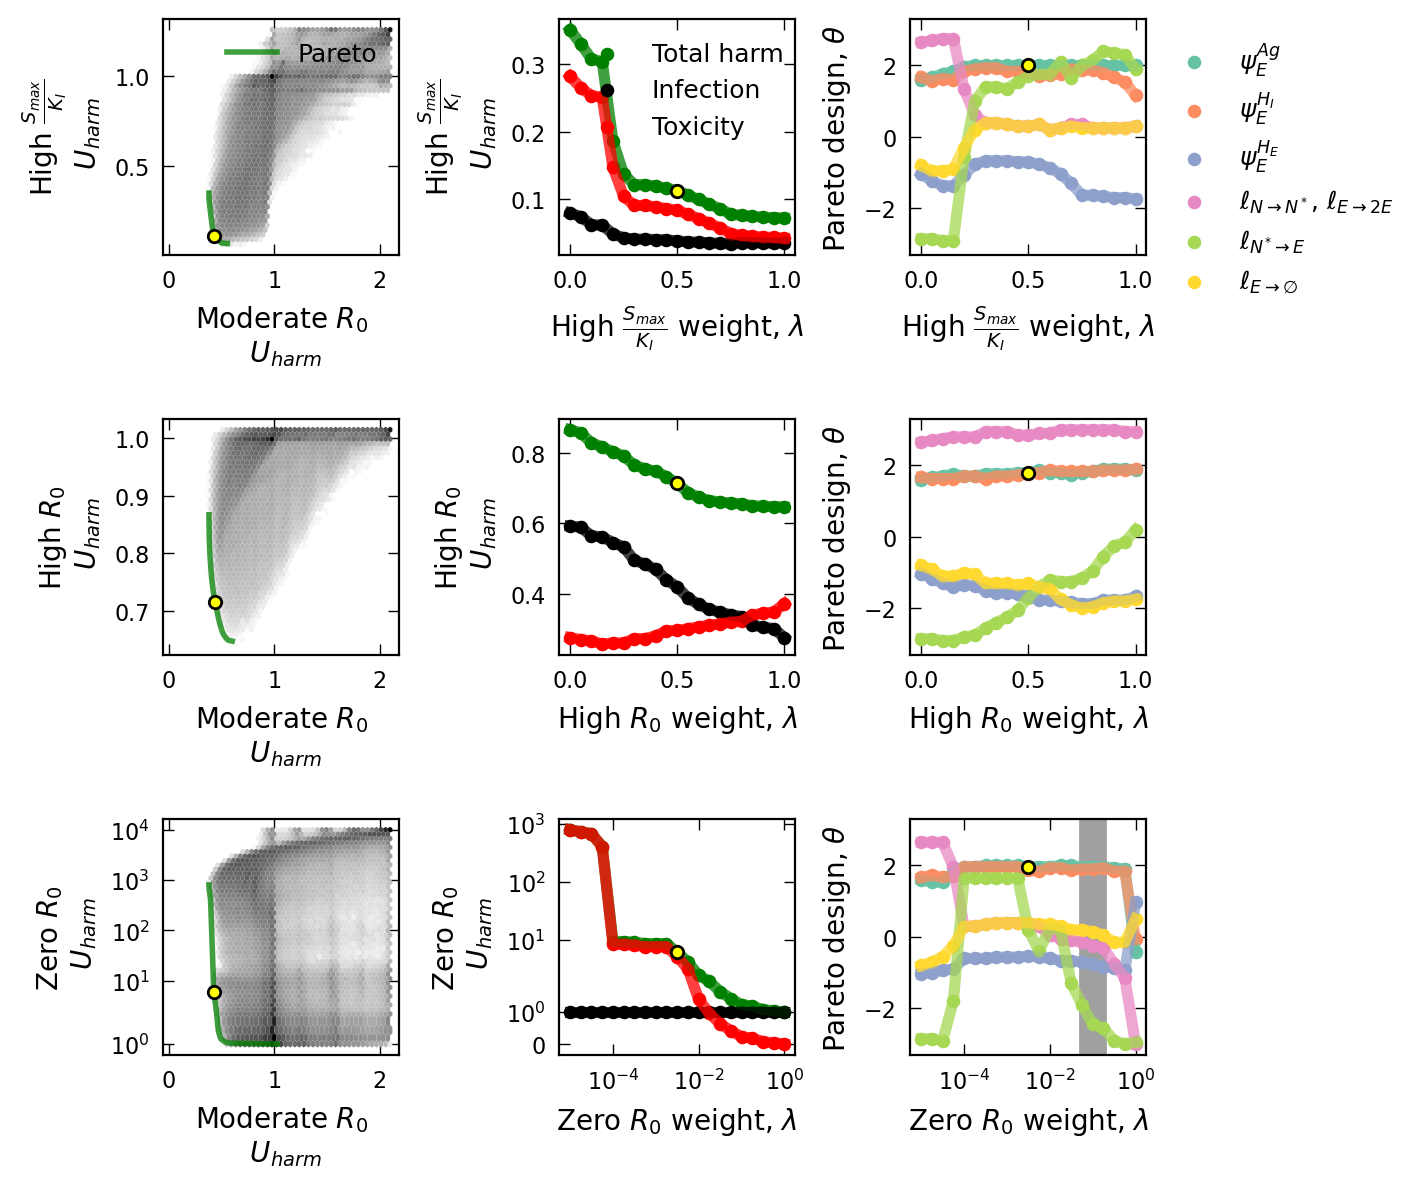

In [51]:
# Visualize pareto regulation
perf = 0
kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

subsets = [[1,0], [1,2], [1,3]]
fig, axs = plt.subplots(len(subsets), 3, figsize=(7, len(subsets)*2), sharex=False, sharey=False,layout='constrained')

for k, [a, b] in enumerate(subsets):
    # (a) Effect of H_E ablation on Harm
    a_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == a)]
    b_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == b)]
    
    plot_data = a_group.loc[a_group.peff_scaled_total_harm > 0].merge(b_group[opt_vars + perf_vars + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))

    # im = axs[k,0].scatter(plot_data['peff_scaled_total_harm'].values, 
    #                       plot_data['peff_scaled_total_harm_comp'].values,
    #                       s = 2, color = "gray",
    #                       #c = plot_data[opt_vars[2]], cmap='Purples', 
    #                       edgecolors = 'None')
    
    im = axs[k,0].hexbin(plot_data['peff_scaled_total_harm'].values, 
                         plot_data['peff_scaled_total_harm_comp'].values,
                         gridsize = 40, C = None, yscale='log' if k == 2 else 'linear',
                         cmap='Grays', edgecolors = 'None',
                         norm = mpl.colors.LogNorm())

    if k == 2:
        lambdas = np.logspace(-6,0, 21)
    else:
        lambdas = np.linspace(0,1, 21) 

    # axs[4,0].set_yscale('symlog')
    #axs[k,0].set_ylim(None,0.5)

    pareto_designs = []

    # In
    for l in lambdas:
        plot_data.loc[:,'compromise'] = (1-l)*plot_data['peff_scaled_total_harm'].values + l*plot_data['peff_scaled_total_harm_comp'].values
        data_sorted = plot_data.sort_values(by='compromise', ascending= True)
        max_row = data_sorted.head(10).mean()
        pareto_designs.append(max_row.values) # plot_data.loc[pareto_index]
    
    pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())

    axs[k,0].plot(pareto_design_df['peff_scaled_total_harm'].values, 
                  pareto_design_df['peff_scaled_total_harm_comp'].values,
                  color='green', linewidth = 2.0, alpha = 0.75,
                 label = "Pareto" if k == 0 else "")
    
    axs[k,0].scatter(pareto_design_df['peff_scaled_total_harm'].values[int(len(lambdas)/2)], 
                     pareto_design_df['peff_scaled_total_harm_comp'].values[int(len(lambdas)/2)],
                     s = 20,
                     color='yellow', edgecolors = 'black', zorder = 2)

    for l, perf in enumerate(perf_vars[0:3]):
        axs[k,1].plot(lambdas,
                      pareto_design_df[perf+'_comp'].values/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
                      color = perf_var_colors[l],
                      **kwargs)
        
        axs[k,1].scatter(lambdas,
                         pareto_design_df[perf+'_comp'].values/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
                         color = perf_var_colors[l],
                         s = 15,
                         label = perf_labels[l])

    axs[k,1].scatter(lambdas[int(len(lambdas)/2)], 
                     pareto_design_df[perf_vars[0]+'_comp'].values[int(len(lambdas)/2)],
                 s = 20,
                 color='yellow', edgecolors = 'black', zorder = 7)
    
    for i, var in enumerate(opt_vars[0:3] + reg_bl):
        axs[k,2].plot(lambdas,
                      pareto_design_df[var].values,
                      color = cmap_colors[i], 
                                **kwargs)
        axs[k,2].scatter(lambdas,
                         pareto_design_df[var].values,
                         label = (opt_vars_labels[0:3] + reg_bl_label)[i],
                         s = 15,
                         color = cmap_colors[i])

    axs[k,2].scatter(lambdas[int(len(lambdas)/2)], 
                 pareto_design_df[opt_vars[0]].values[int(len(lambdas)/2)],
             s = 20,
             color='yellow', edgecolors = 'black', zorder = 7)

    # axs[4,1].set_yscale('symlog')

    axs[k,0].set_ylabel(phase_cluster_labels[b]+"\n"+r" $U_{harm}$", fontsize = 10)
    axs[k,0].set_xlabel(phase_cluster_labels[a]+"\n"+r" $U_{harm}$", fontsize = 10)
    
    axs[k,1].set_ylabel(phase_cluster_labels[b]+"\n"+r" $U_{harm}$", fontsize = 10)
    axs[k,1].set_xlabel(phase_cluster_labels[b] + " weight, " +r"$\lambda$", fontsize = 10)

    axs[k,2].set_xlabel(phase_cluster_labels[b] + " weight, " +r"$\lambda$", fontsize = 10)
    axs[k,2].set_ylabel(r"Pareto design, $\theta$", fontsize = 10)
    axs[k,2].set_ylim(-1.1*L0_max, 1.1*L0_max)

axs[2,0].set_yscale('symlog')
axs[2,1].set_yscale('symlog')
axs[0,0].legend(fontsize=9, framealpha=0, ncol = 1)
axs[0,1].legend(fontsize=9, framealpha=0, ncol = 1)
axs[0,2].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=9)
#axs[0,0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Store critical regulatory design
acute_pareto_reg_index = np.argmin(np.abs(lambdas - 0.1))
acute_pareto_reg = pareto_design_df[opt_vars[0:3] + reg_bl].values[acute_pareto_reg_index]
axs[2,2].axvline(x = lambdas[acute_pareto_reg_index], color = 'gray', linewidth = 10, alpha = 0.75, zorder = 0)

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    # ax.locator_params(axis='y', nbins=4)
    if j <= 6:
        ax.locator_params(axis='x', nbins=4)
    else:
        ax.semilogx()
    #ax.set_ylim(None, 0.5)
    ax.set_xlim(-0.05, None)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-prot_compare_phases'+'.pdf', format="pdf", transparent=True, dpi=150) #, bbox_inches="tight")

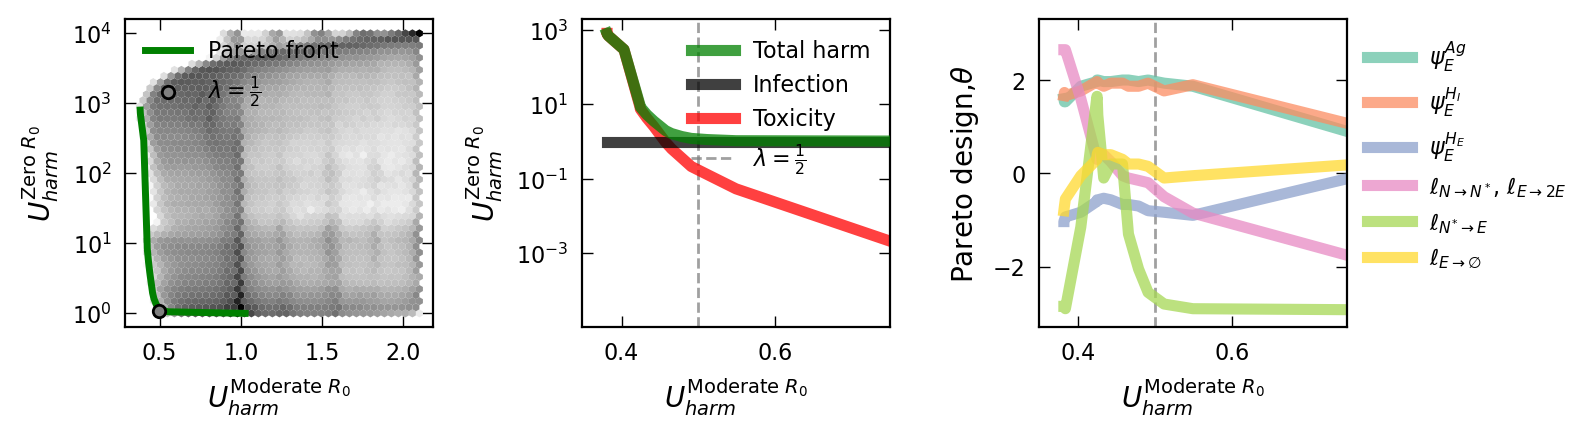

In [104]:
# Visualize pareto regulation
perf = 0

fig, axs = plt.subplots(1, 3, figsize=(8, 2), sharex=False, sharey=False) #, layout='constrained')

lambdas = np.logspace(-6,0, 21)
ag_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 1)]
lowR0_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 3)]

plot_data = ag_group.loc[ag_group.peff_scaled_total_harm > 0].merge(lowR0_group[opt_vars + perf_vars + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))

# im = axs[0].scatter(plot_data['peff_scaled_total_harm'].values, 
#                       plot_data['peff_scaled_total_harm_comp'].values,
#                       s = 2, color = "gray",
#                       #c = plot_data[opt_vars[2]], cmap='Purples', 
#                       edgecolors = 'None')

im = axs[0].hexbin(plot_data['peff_scaled_total_harm'].values, 
                     plot_data['peff_scaled_total_harm_comp'].values,
                     gridsize = 40, C = None,  yscale='log',
                     cmap='Grays', edgecolors = 'None',
                     norm = mpl.colors.LogNorm())

pareto_designs = []

# In
for l in lambdas:
    plot_data.loc[:,'compromise'] = (1-l)*plot_data['peff_scaled_total_harm'].values + l*plot_data['peff_scaled_total_harm_comp'].values
    plot_data.loc[:,'lambda'] = l
    data_sorted = plot_data.sort_values(by='compromise', ascending= True)
    max_row = data_sorted.head(10).mean()
    pareto_designs.append(max_row.values) # plot_data.loc[pareto_index]

equal_design = plot_data.loc[(plot_data['peff_scaled_total_harm'] + plot_data['peff_scaled_total_harm_comp']).idxmin()]
pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())

axs[0].plot(pareto_design_df['peff_scaled_total_harm'].values, 
              pareto_design_df['peff_scaled_total_harm_comp'].values,
              color='green', linewidth = 2.5, alpha = 1.0,
           label = "Pareto front")

axs[0].scatter(equal_design['peff_scaled_total_harm'], 
               equal_design['peff_scaled_total_harm_comp'],
               label = r"$\lambda = \frac{1}{2}$",
       s = 20,
       color='grey', edgecolors = 'black', zorder = 2)

for l, perf in enumerate(perf_vars[0:3]):
    axs[1].plot(pareto_design_df[perf_vars[0]].values,
                  pareto_design_df[perf+'_comp'].values/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
                  color = perf_var_colors[l],
                zorder = 3 - l,
                label = perf_labels[l], 
                **kwargs)
    
    # axs[1].scatter(pareto_design_df[perf_vars[0]].values,
    #                  pareto_design_df[perf+'_comp'].values/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
    #                  color = perf_var_colors[l],
    #                  s = 15,
    #                  label = perf_labels[l])

for i, var in enumerate(opt_vars[0:3] + reg_bl):
    axs[2].plot(pareto_design_df[perf_vars[0]].values,
                  pareto_design_df[var].values,
                label = (opt_vars_labels[0:3] + reg_bl_label)[i],
                  color = cmap_colors[i], **kwargs)
                # linewidth = 2, alpha = 0.75)
    
    # axs[2].scatter(pareto_design_df[perf_vars[0]].values,
    #                  pareto_design_df[var].values,
    #                  label = (opt_vars_labels[0:3] + reg_bl_label)[i],
    #                  s = 15,
    #                  color = cmap_colors[i])

axs[1].axvline(x = equal_design.peff_scaled_total_harm, 
               color = 'grey', linewidth = 1, alpha = 0.75, linestyle = '--', zorder = 0,
               label = r"$\lambda = \frac{1}{2}$")
axs[2].axvline(x = equal_design.peff_scaled_total_harm, color = 'grey', linewidth = 1, alpha = 0.75, linestyle = '--', zorder = 0)
axs[1].set_xlim(None, 0.75)
axs[1].semilogy()
# axs[1].set_yscale('symlog')

r'$\Delta \frac{U_{infection}^{opt}}{U_{harm}^{E = 0}}$'

axs[0].set_ylabel(r"$\frac{U_{harm}^{\text{Zero } R_0}}{U_{harm}^{E = 0}}$", fontsize = 12)
axs[0].set_xlabel(r"$\frac{U_{harm}^{\text{Moderate } R_0}}{U_{harm}^{E = 0}}$", fontsize = 12)

axs[1].set_ylabel(r"$\frac{U_{harm}^{\text{Zero } R_0}}{U_{harm}^{E = 0}}$", fontsize = 12)
axs[1].set_xlabel(r"$\frac{U_{harm}^{\text{Moderate } R_0}}{U_{harm}^{E = 0}}$", fontsize = 12)

axs[2].set_xlabel(r"$\frac{U_{harm}^{\text{Moderate } R_0}}{U_{harm}^{E = 0}}$", fontsize = 12)
axs[2].set_ylabel("Pareto design, "+ r"$\theta$", fontsize = 10)
axs[2].set_ylim(-1.1*L0_max, 1.1*L0_max)
axs[2].set_xlim(None, 0.75)

axs[0].legend(fontsize=8, loc='upper left', framealpha=0)
axs[1].legend(fontsize=8, loc='upper right', framealpha=0)
axs[2].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)

# Store critical regulatory design
acute_pareto_reg = equal_design[opt_vars[0:3] + reg_bl].values #pareto_design_df[opt_vars[0:3] + reg_bl].values[np.argmin(np.abs(lambdas - 1/2))]

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.4, hspace=0.4)

plt.savefig('_figs/fig5_'+comment+'-pareto-prot_combined_phases'+'.pdf', format="pdf", transparent=True, dpi=150) #, bbox_inches="tight")

/tmp/ipykernel_10364/3765575566.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data.loc[:,'compromise'] = (1 - l)*plot_data['max_pE'].values/np.amax(plot_data['max_pE'].values) + l*plot_data['peff_scaled_total_harm'].values/np.amax(np.abs(plot_data['peff_scaled_total_harm'].values))
/tmp/ipykernel_10364/3765575566.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data.loc[:,'compromise'] = (1 - l)*plot_data['max_pE'].values/np.amax(plot_data['max_pE'].values) + l*plot_data['peff_scaled_to

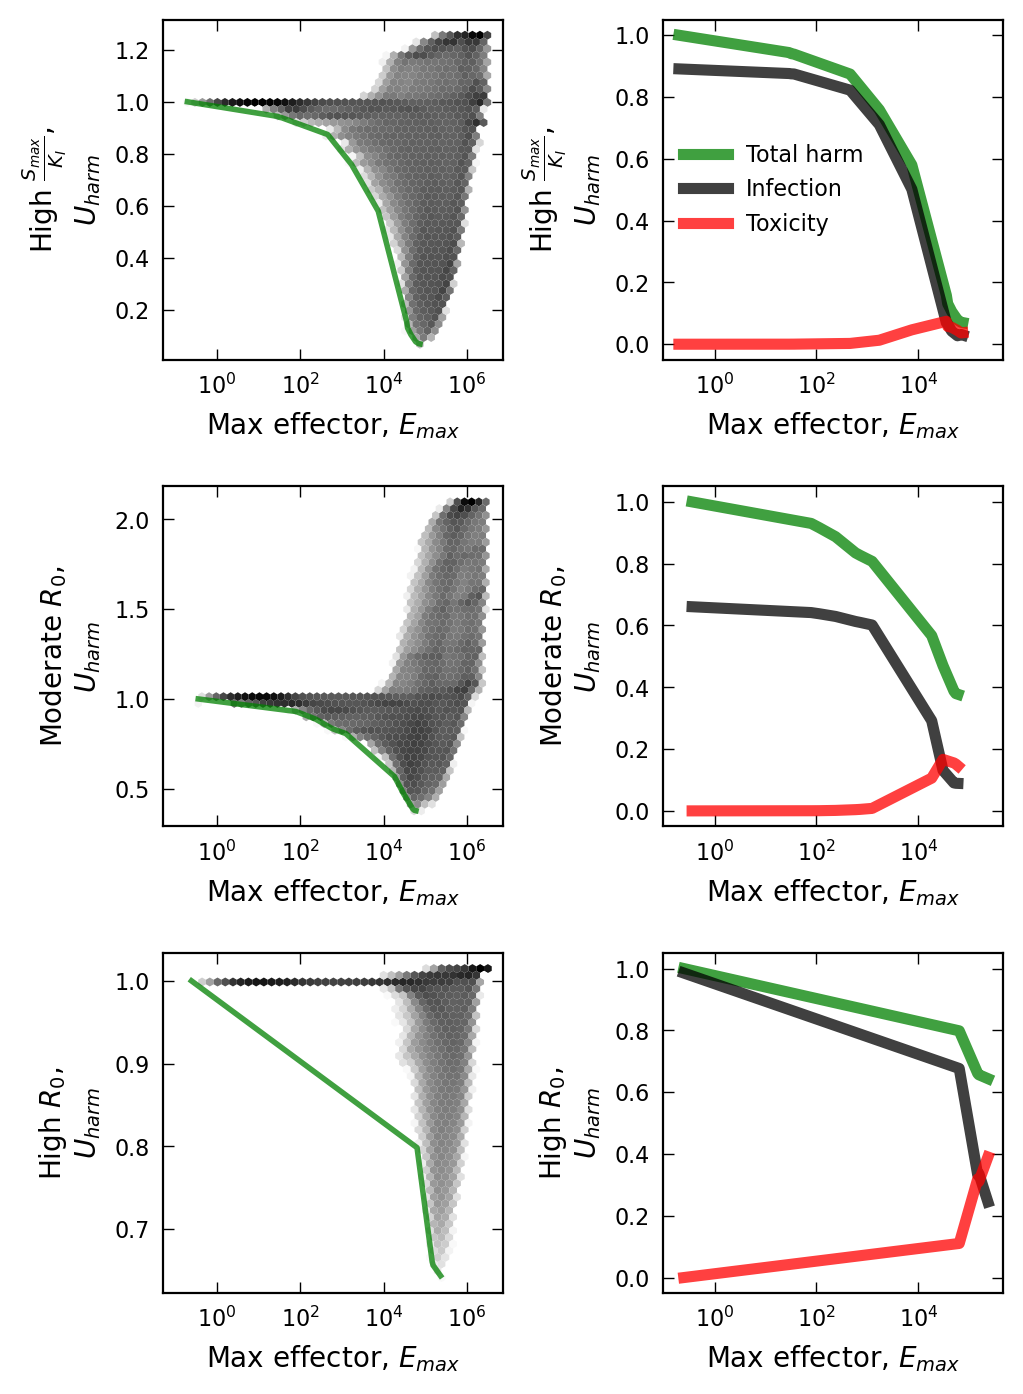

In [54]:
# Visualize pareto regulation
perf = 0

fig, axs = plt.subplots(3, 2, figsize=(5, 3*2 + 1), sharex='col', sharey=False,layout='constrained')

lambdas = np.logspace(-6,0, 21)

for k, b in enumerate([0,1,2]):
    # (a) Effect of H_E ablation on Harm
    plot_data = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == b)*(avg_cluster_data.max_pE > 0)]

    # im = axs[k,0].scatter(plot_data['max_pE'].values,
    #                       plot_data['peff_scaled_total_harm'].values,
    #                       s = 2,
    #                       c = plot_data[opt_vars[2]], cmap='coolwarm_r',
    #                       edgecolors = 'None')

    im = axs[k,0].hexbin(plot_data['max_pE'].values,
                         plot_data['peff_scaled_total_harm'].values,
                         gridsize = 40, C = None,  
                         xscale='log',
                         yscale='linear',
                         cmap='Grays', edgecolors = 'None',
                         norm = mpl.colors.LogNorm())

    # axs[2,0].set_yscale('symlog')
    # axs[k,0].semilogx()
    # axs[k,0].set_ylim(None,0.5)

    pareto_designs = []

    # In
    for l in lambdas:
        plot_data.loc[:,'compromise'] = (1 - l)*plot_data['max_pE'].values/np.amax(plot_data['max_pE'].values) + l*plot_data['peff_scaled_total_harm'].values/np.amax(np.abs(plot_data['peff_scaled_total_harm'].values))
        data_sorted = plot_data.sort_values(by='compromise', ascending= True)
        max_row = data_sorted.head(3).mean()
        #pareto_index = np.argmax((1 - l)*plot_data['peff_scaled_total_harm'].values + l*plot_data['peff_scaled_total_harm_comp'].values)

        pareto_designs.append(max_row) # plot_data.loc[pareto_index]

    pareto_design_df = pd.concat(pareto_designs)

    axs[k,0].plot(pareto_design_df['max_pE'].values, 
                  pareto_design_df['peff_scaled_total_harm'].values,
              color='green', linewidth = 2.0, alpha = 0.75,
             label = "Pareto" if k == 0 else "")

    for l, perf in enumerate(perf_vars[0:3]):
        axs[k,1].plot(pareto_design_df['max_pE'].values,
                      pareto_design_df[perf].values,
                      color = perf_var_colors[l],
                      label = perf_labels[l],
                      **kwargs)
        
        # axs[k,1].scatter(pareto_design_df['max_pE'].values,
        #                  pareto_design_df[perf].values,
        #                  color = perf_var_colors[l],
        #                  s = 20,
        #                  label = perf_labels[l])

    axs[k,0].set_ylabel(phase_cluster_labels[b]+',\n'+r"$U_{harm}$", fontsize = 10)
    axs[k,0].set_xlabel(r'Max effector, $E_{max}$', fontsize = 10)
    
    axs[k,1].set_xlabel(r'Max effector, $E_{max}$', fontsize = 10)
    axs[k,1].set_ylabel(phase_cluster_labels[b]+',\n'+r"$U_{harm}$", fontsize = 10)
    axs[k,1].semilogx()

axs[0,1].legend(fontsize=8, framealpha=0, ncol = 1)

for ax in axs.flat:
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

# fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-clusters_prot_effector'+'.pdf', dpi=150, bbox_inches="tight")

In [80]:
from optimize_nets import *

runs = 10
d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
ps = acute_pareto_reg

psis = np.array([[ps[0], ps[1], ps[2], ps[3], # Na
                 ps[0], ps[1], ps[2], ps[4], # NE
                 -0*ps[0], -0*ps[1], -0*ps[2], -L0_max**4 -0*ps[4], # EM
                 -ps[0], -ps[1], -ps[2], ps[5]]])  # Edie

# run simulations for extreme scenarios
# run(batch = [-1], outdir=d, inf_sample = infection_sample, 
#     comment="acute_pareto_reg_sim", runs = runs, infection_model = '', 
#     default_reg = psis,
#     num_cpu = num_cpu)

d_file = d + '/sim_batch_-1-10--acute_pareto_reg_sim.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
crit_reg_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names]).merge(cluster_input[['K_I', 'b_I', 'K_H', 'N_0','I_0'] + ['phase_cluster']], how = 'left', on = ['K_I', 'b_I', 'K_H', 'N_0','I_0'])

crit_reg_data.loc[:, 'R_0'] = crit_reg_data['S_0']*crit_reg_data['b_I']/crit_reg_data['d_I'] - 1
crit_reg_data.loc[:,opt_vars[0:3]] = np.round(crit_reg_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values, 3)
crit_reg_data.loc[:,opt_vars[3:]] = np.round(1/(1 + np.exp(-crit_reg_data[reg_bl].values)), 3)
crit_reg_data.loc[:,"harm_pI_noprotection"] = crit_reg_data.apply(lambda row: np.mean(cluster_input.harm_pI_noprotection.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))]), axis=1)

crit_reg_data.loc[:,"peff_infection"] = crit_reg_data['harm_pI']/S_0
crit_reg_data.loc[:,"peff_toxicity"] = crit_reg_data['harm_pS']/S_0
crit_reg_data.loc[:,"peff_scaled_total_harm"] = (crit_reg_data['peff_infection'] + crit_reg_data['peff_toxicity'])/crit_reg_data["harm_pI_noprotection"]

crit_eff_dyn_design = crit_reg_data.groupby(plots, as_index = False, sort = True).mean()
crit_eff_dyn_design.loc[:,"del_peff_scaled_total_harm"] = crit_eff_dyn_design.peff_scaled_total_harm - cluster_input.peff_scaled_total_harm.values
crit_eff_dyn_design.loc[:,"del_peff_infection_scaled"] = (crit_eff_dyn_design.peff_infection - cluster_input.peff_infection.values)/crit_eff_dyn_design.harm_pI_noprotection
crit_eff_dyn_design.loc[:,"del_peff_toxicity_scaled"] = (crit_eff_dyn_design.peff_toxicity - cluster_input.peff_toxicity.values)/crit_eff_dyn_design.harm_pI_noprotection

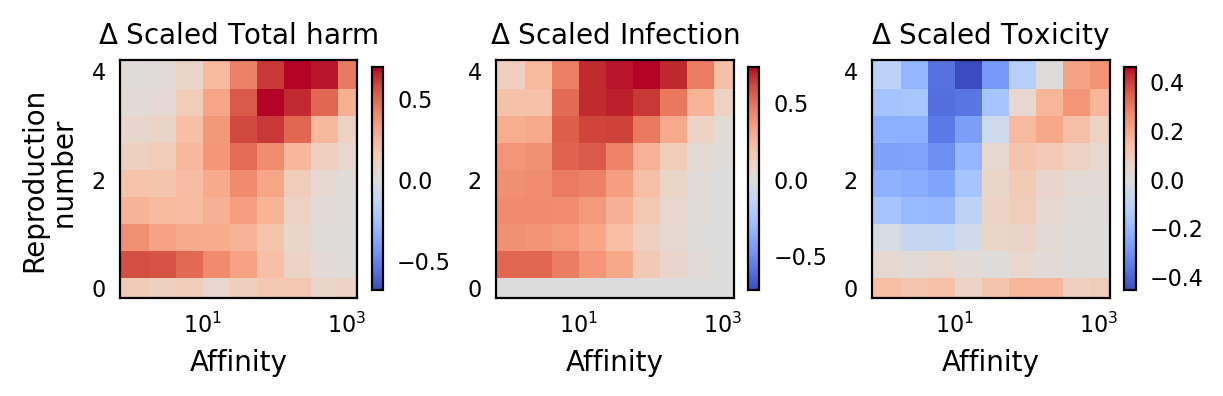

In [81]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(1, 3, 
                          figsize=(6, 2), sharex=True, sharey=True, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = ['del_peff_scaled_total_harm', 'del_peff_infection_scaled', 'del_peff_toxicity_scaled'] # 'harm_pI_noprotection'
data = crit_eff_dyn_design

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    range = np.amax(np.abs(z))
    im = ax.scatter(S_0/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='coolwarm', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    z_label = (['Scaled ' + perf_labels[0], 'Scaled ' + perf_labels[1], 'Scaled ' + perf_labels[2]] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    ax.set_title(r"$\Delta$ "+z_label, fontsize = 10.0)
    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    cb = fig.colorbar(im, ax=ax, location='right', shrink = 0.6, pad = 0.025)
    # cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/figSI_'+comment+'-reg-singles_prot_delta_crit_reg_hmap'+'.pdf', dpi=300) #, bbox_inches="tight")

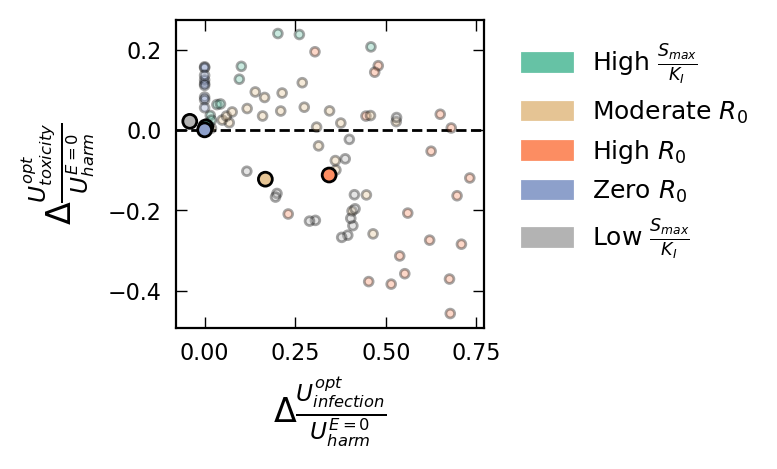

In [98]:
row_labels = opt_vars_labels[0:3] + reg_bl_label
col_labels = phase_cluster_labels #[phase_clusters.tolist()
opt_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0][opt_vars[0:3] + reg_bl].values/np.array(3*[psi_max] + 3*[L0_max])).T

fig, ax = plt.subplots(figsize=(2, 2))

plot_data = crit_eff_dyn_design.groupby('phase_cluster', as_index = False).mean()
ax.scatter((plot_data.peff_infection.values - cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].peff_infection.values)/plot_data.harm_pI_noprotection.values, 
           plot_data.peff_toxicity.values - cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].peff_toxicity.values/plot_data.harm_pI_noprotection.values,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 25, edgecolors = 'black', zorder = 2)

ax.scatter(crit_eff_dyn_design.del_peff_infection_scaled, 
           crit_eff_dyn_design.del_peff_toxicity_scaled,
               c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
               s = 10, edgecolors = 'black', zorder = 1, alpha = 0.35)

legend_handles = []
for key, color in enumerate([cluster_colors[i] for  i in phase_clusters]):
    patch = mpatches.Patch(color=color, label=str(phase_cluster_labels[key]))
    legend_handles.append(patch)

ax.axhline(y = 0.0, linestyle = '--', color = 'black', zorder = 0)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1.0), fontsize=9, framealpha=0, ncol = 1)
ax.locator_params(axis='x', nbins=4)
ax.locator_params(axis='y', nbins=4)

ax.set_xlabel(r'$\Delta \frac{U_{infection}^{opt}}{U_{harm}^{E = 0}}$', fontsize = 12)
ax.set_ylabel(r'$\Delta \frac{U_{toxicity}^{opt}}{U_{harm}^{E = 0}}$', fontsize = 12)

ax.set_box_aspect(1)
ax.minorticks_off()
ax.tick_params(axis='both', which='major', labelsize=8)

plt.savefig('_figs/fig5_'+comment+'-reg-cluster_prot_delta_crit_reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

In [ ]:
# Plot select infection responses
fig, axs = plt.subplots(1,n_clusters, dpi = 300, sharex = 'row', sharey = 'row', figsize=(2*n_clusters, 2))
repeat = 1

# Loop and do 
for k, c in enumerate(phase_clusters):

    # Select infection
    select_cluster_data = cluster_input.loc[cluster_input.phase_cluster == c]
    infection_count = len(select_cluster_data)
    #v = select_cluster_data.loc[select_cluster_data[perf_vars[0]] >= select_cluster_data[perf_vars[0]].median(), vir_vars].iloc[0].values.ravel()
    opt_dyn, pareto_dyn = 0, 0

    for v in select_cluster_data[vir_vars].values:
        # Response optimized for single infection class
        p = cluster_grid_opt.loc[(cluster_grid_opt.perf_index == 0)*(cluster_grid_opt.phase_cluster == c), opt_vars[0:3] + reg_bl].values.ravel()
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[6],
                                  b_I = v[2], 
                                  K_I = v[1],
                                  d_I = v[0],
                                  K_H = v[3],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  duration = 1.0*sim_duration,
                                  steps = 2*sim_steps)
        
        opt_dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]

        # Response optimized for moderate affinity and avoiding self
        p = acute_pareto_reg
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[6],
                                  b_I = v[2], 
                                  K_I = v[1],
                                  d_I = v[0],
                                  K_H = v[3],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  duration = 1.0*sim_duration,
                                  steps = 2*sim_steps)
        
        pareto_dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]

    opt_S, opt_I, opt_E = opt_dyn[:,0]/infection_count, opt_dyn[:,1]/infection_count, opt_dyn[:,4]/infection_count
    pareto_S, pareto_I, pareto_E = pareto_dyn[:,0]/infection_count, pareto_dyn[:,1]/infection_count, pareto_dyn[:,4]/infection_count

    # Plot cell dynamics
    axs[k].plot(ts, pareto_E/S_0, linewidth=2.0, color = 'green', alpha = 0.8, label = "Effector, $E$")
    axs[k].plot(ts, pareto_I/S_0, linewidth=2.0, color = 'red', alpha = 0.8, label = "Infected, $I$")
    axs[k].plot(ts, opt_E/S_0, linewidth=2.0, color = 'green', alpha = 0.8, linestyle = '--')
    axs[k].plot(ts, opt_I/S_0, linewidth=2.0, color = 'red', alpha = 0.8, linestyle = '--')
    
    axs[k].set_title(phase_cluster_labels[k], fontsize = 7.5)

axs[0].legend(loc = 'upper right', fontsize=6, framealpha=0, ncol = 1)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    ax.set_ylabel(r'Cell count [$S_{max}$]', fontsize = 8.5)
    ax.set_xlabel(r"Time [day]", fontsize = 8.5)
    ax.semilogy()
    ax.set_ylim(1/S_0, None)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.55, hspace=0.25)

plt.savefig('_figs/fig5_'+comment+'-pareto-design-effect-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300)

##### Relationship between feedback strength and performance

In [24]:
# Compute optimal performance as a function of allowed feedback strength
cluster_feedback_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 6)(delayed(grid_search)(g, type = 'global', top = 10)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster', 'feedback'],as_index = False)
                                                  ))

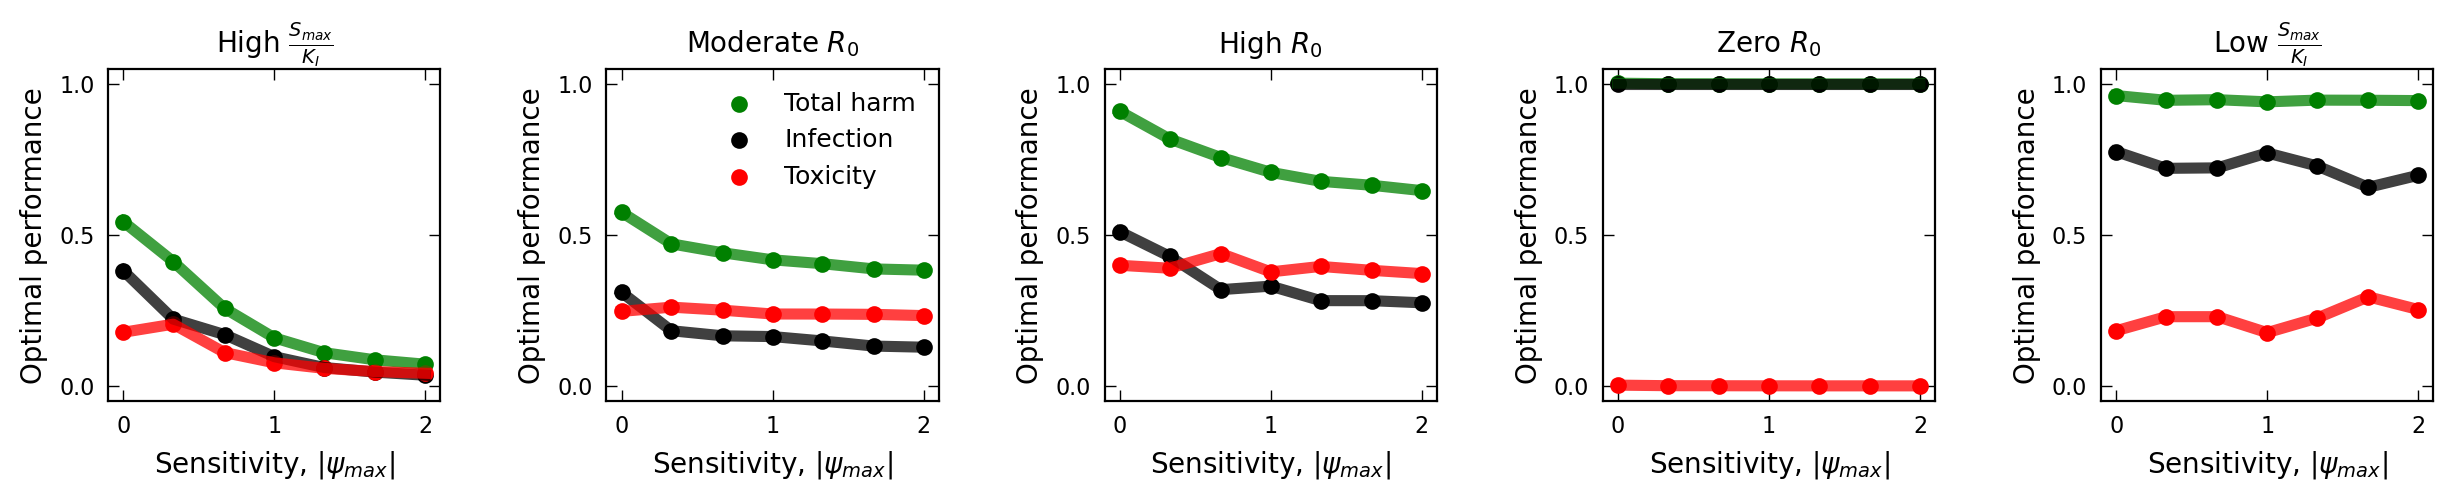

In [25]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, perf in enumerate(perf_vars[0:3]):
        axs.flat[k].plot(g['feedback'].values,
             g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
             color = perf_var_colors[i],
                            **kwargs)
    
        axs.flat[k].scatter(g['feedback'].values,
         g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
         color = perf_var_colors[i], 
         label = perf_labels[i])

    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[1].legend(fontsize=9, framealpha=0, ncol = 1)

for ax in axs.flat: 
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Optimal performance", fontsize = 10)
    ax.set_xlabel(r"Sensitivity, $|\psi_{max}|$", fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-prot_feedback'+'.pdf', dpi=300, bbox_inches="tight")

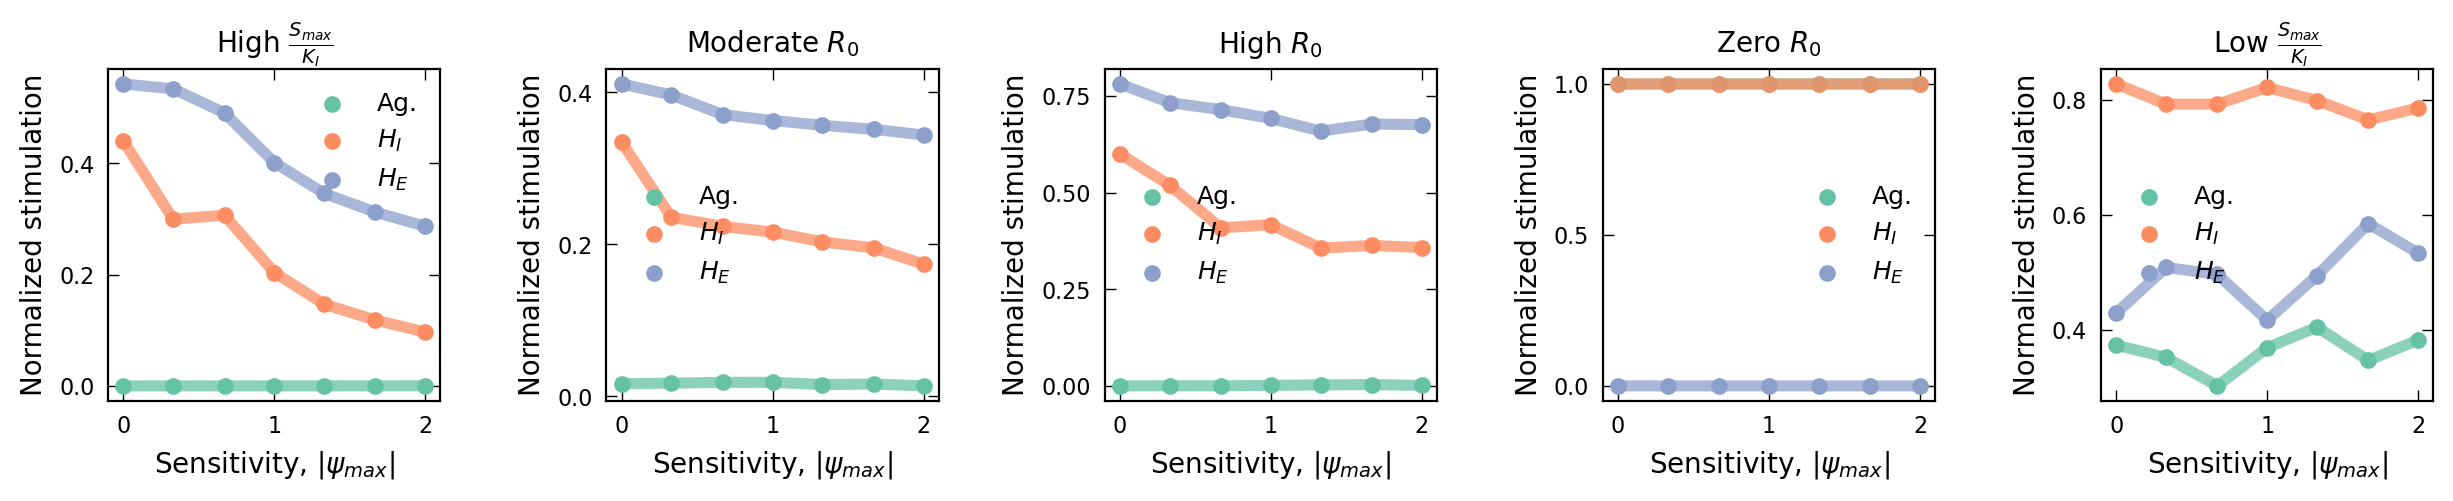

In [26]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, stim in enumerate(stim_vars):
        normalize = np.amax(avg_cluster_data.loc[(avg_cluster_data.phase_cluster == k), stim])
        axs[k].plot(g['feedback'].values,
             g[stim].values/normalize,
             color = cmap_colors[i],
                            **kwargs)
    
        axs[k].scatter(g['feedback'].values,
         g[stim].values/normalize,
         color = cmap_colors[i], 
         label = ['Ag.', r'$H_I$', r'$H_E$'][i])

    axs[k].set_title(phase_cluster_labels[k], fontsize = 10.0)

for ax in axs.flat:
    ax.legend(fontsize=9, framealpha=0)
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Normalized stimulation", fontsize = 10)
    ax.set_xlabel("Sensitivity, $|\psi_{max}|$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-prot_stim_feedback'+'.pdf', dpi=150, bbox_inches="tight")

Paradoxically, for a response to be protective, it drives down the infection feedback signals.

##### Relationship between design and performance

In [133]:
# Compute optimal performance as a function of each individual single design 
# ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
#                           batch_size = 1)(delayed(grid_search)(g, type = 'ablate', top = 25)
#                                                    for (_, g) in cluster_sim_df.groupby(vir_vars)
#                                                   ))

cluster_ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 1)(delayed(grid_search)(g, type = 'ablate', top = 10)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster'], as_index = False)
                                                  ))

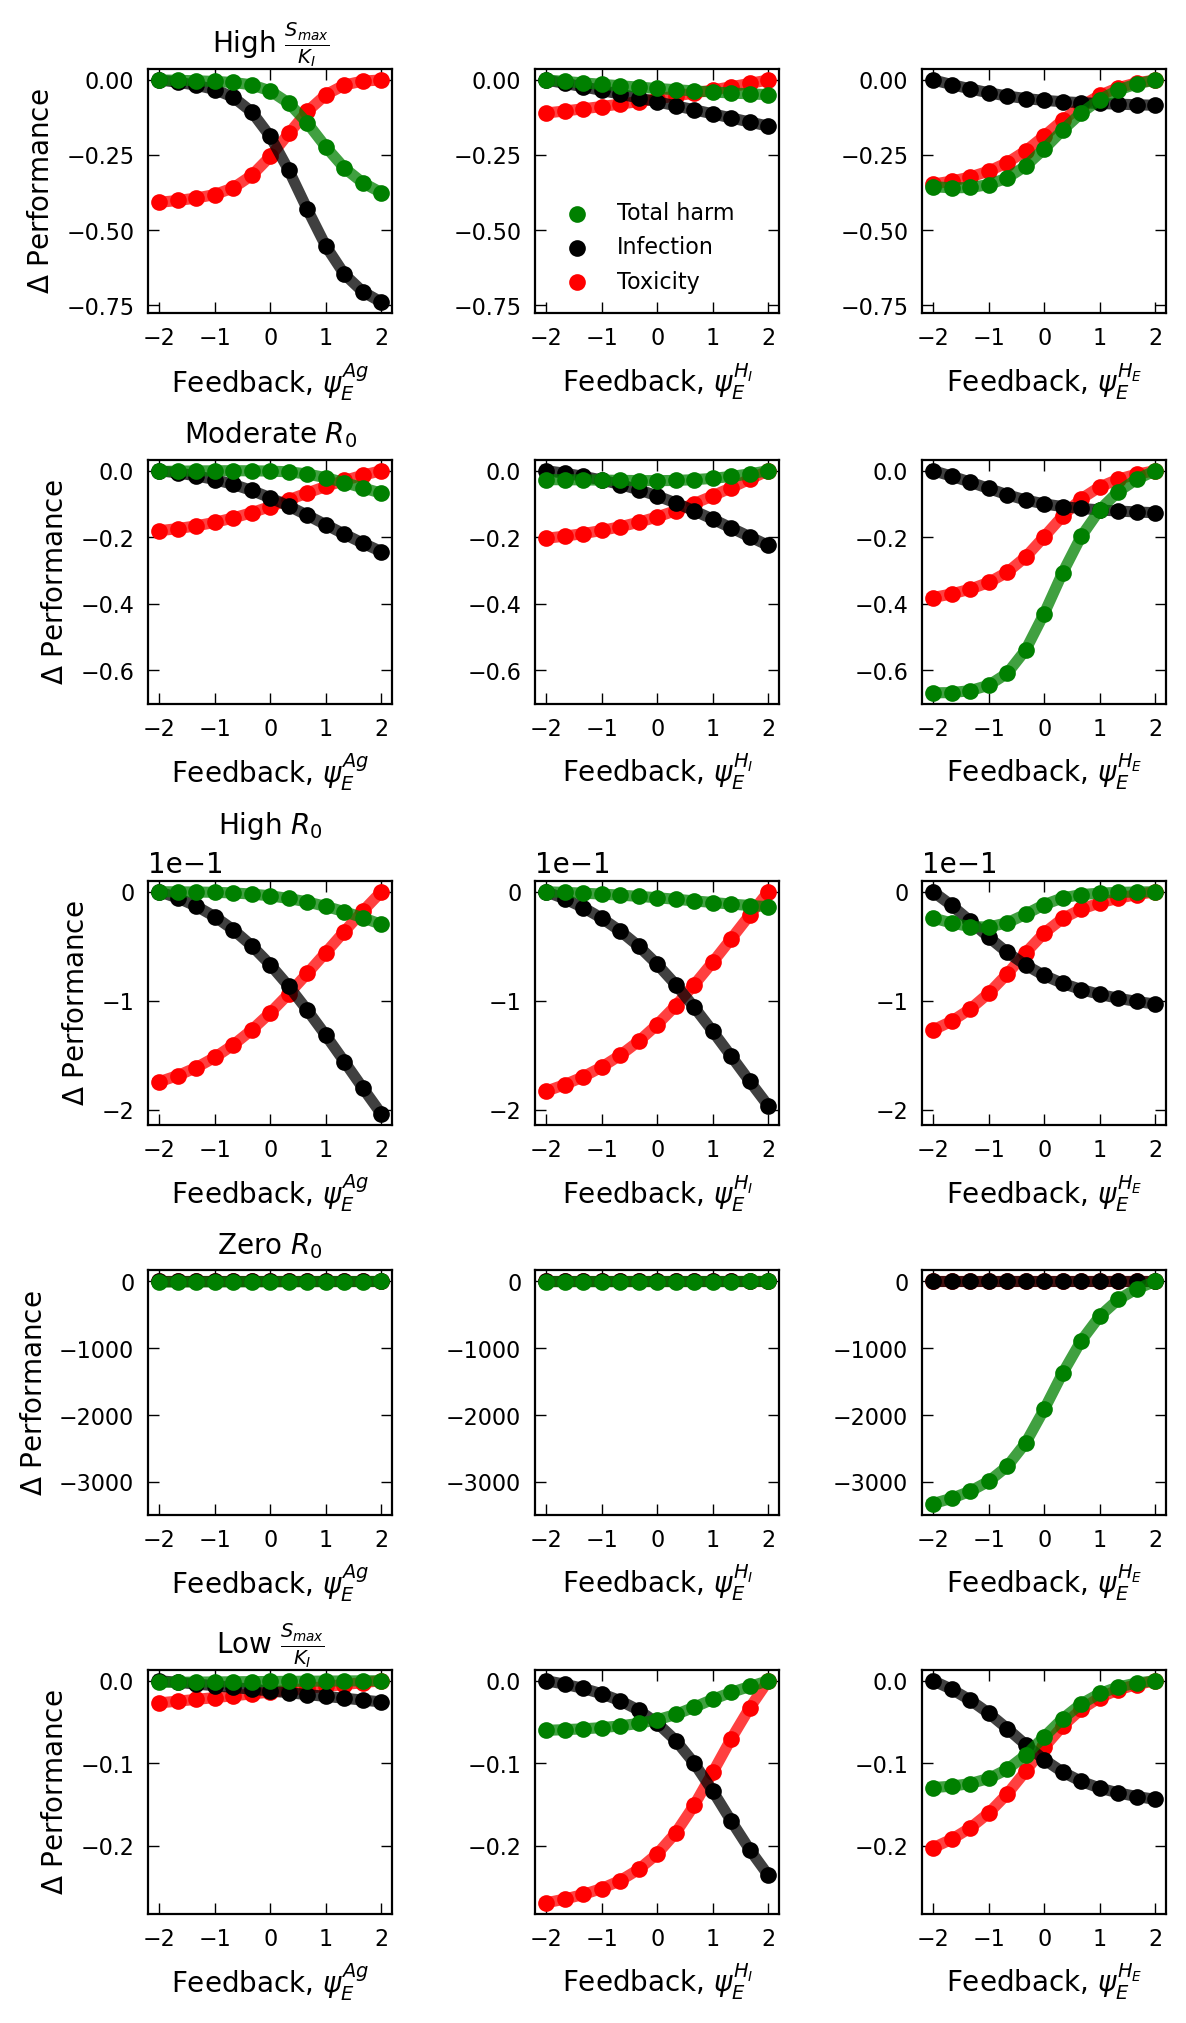

In [134]:
# Make trade-off figure
fig, axs = plt.subplots(n_clusters,3, figsize=(3*2, n_clusters*2), sharex='row', sharey='row',layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = avg_cluster_data #cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on Infection
    for i, var in enumerate(opt_vars[0:3]):
        use_data = g.groupby([var], as_index = False).mean()
        for l, perf in enumerate(perf_vars[0:3]):
            axs[k,i].plot(use_data[var].values,
                          use_data[perf].values - np.amax(use_data[perf].values),
                          color = ['green','black', 'red'][l],
                          zorder = 3 - l,
                                **kwargs)
    
            axs[k,i].scatter(use_data[var].values,
                             use_data[perf].values - np.amax(use_data[perf].values),
                             label = perf_labels[l],
                             zorder = 3 - l,
                             color = ['green','black', 'red'][l])

    axs[k,0].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[1].legend(fontsize=8, framealpha=0, ncol = 1)
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    #ax.set_ylim(-0.05, None)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=6)
    if j % 3 == 0:
        ax.set_ylabel(r"$\Delta$ Performance", fontsize = 10)
    ax.set_xlabel(r"Feedback, " + opt_vars_labels[j % 3], fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    if j // 3 == 2:
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.savefig('_figs/figSI_'+comment+'-perf_feedback_effect'+'.pdf', dpi=300, bbox_inches="tight")

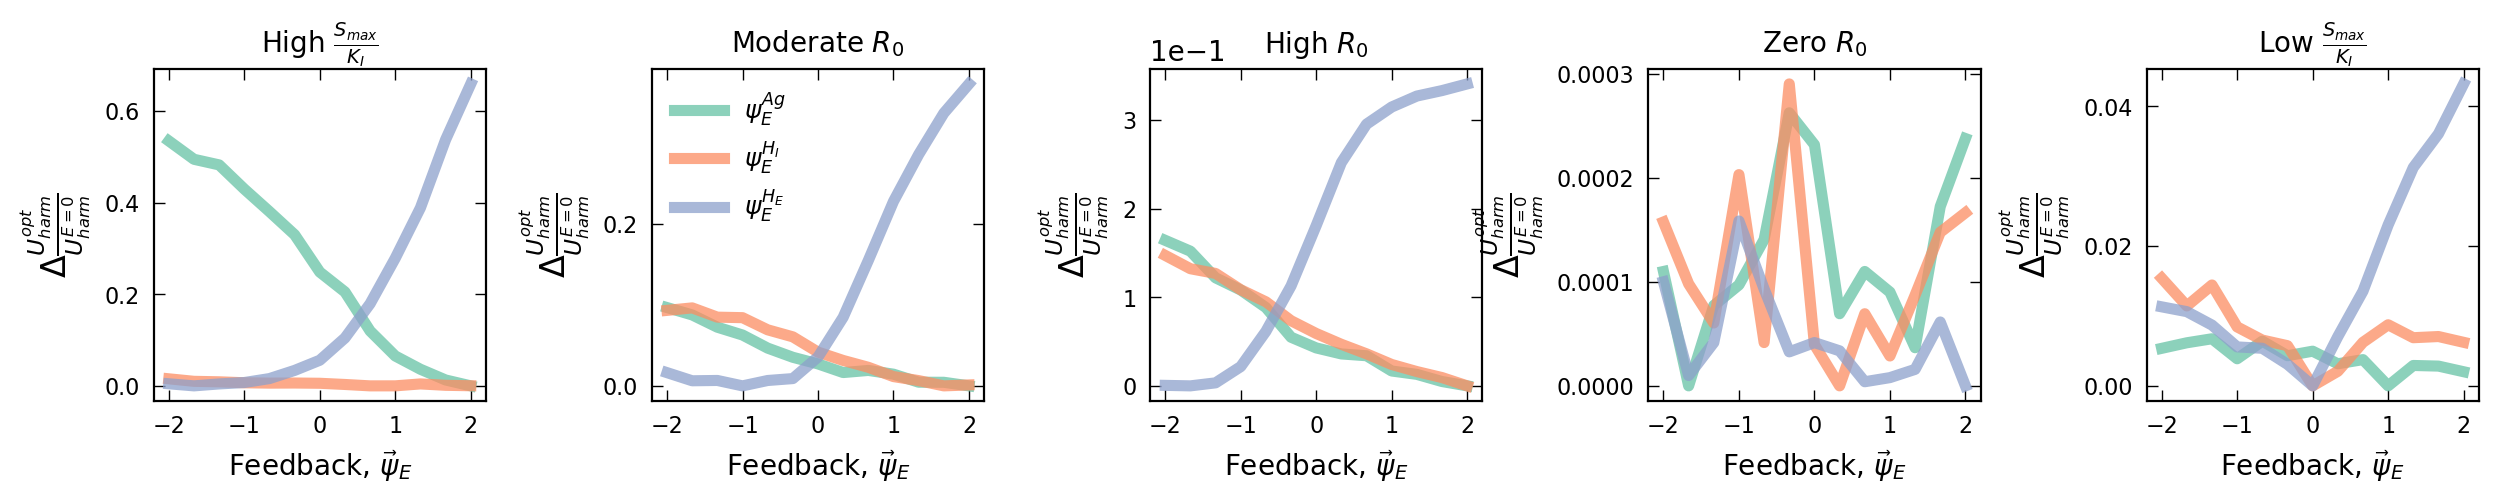

In [141]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on Infection
    for i, var in enumerate(opt_vars[0:3]):
        axs.flat[k].plot(g.loc[(g.ablate_index == i),  [var]].values,
             g.loc[(g.ablate_index == i), [perf_vars[perf]]].values - np.amin(g.loc[(g.ablate_index == i), [perf_vars[perf]]].values),
             color = cmap_colors[i], 
                         label = opt_vars_labels[i],
                            **kwargs)

        # axs.flat[k].scatter(g.loc[(g.ablate_index == i),  [var]].values,
        #                     g.loc[(g.ablate_index == i), [perf_vars[perf]]].values - np.amax(g.loc[(g.ablate_index == i), [perf_vars[perf]]].values),
        #                     label = opt_vars_labels[i],
        #                     color = cmap_colors[i])

    #axs.flat[k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[1].legend(fontsize=9, framealpha=0, ncol = 1)
axs.flat[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    #ax.set_ylim(-0.05, None)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=6)
    ax.set_ylabel(r'$\Delta \frac{U_{harm}^{opt}}{U_{harm}^{E = 0}}$', fontsize = 12)
    if j // n_clusters == 0:
        ax.set_xlabel(r"Feedback, $\vec\psi_E$", fontsize = 10)
    else:
        ax.set_xlabel("Baseline\n" +r"regulation, $\vec g_0$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/fig4_'+comment+'-pareto-prot_ablate_feedback'+'.pdf', dpi=300, bbox_inches="tight")

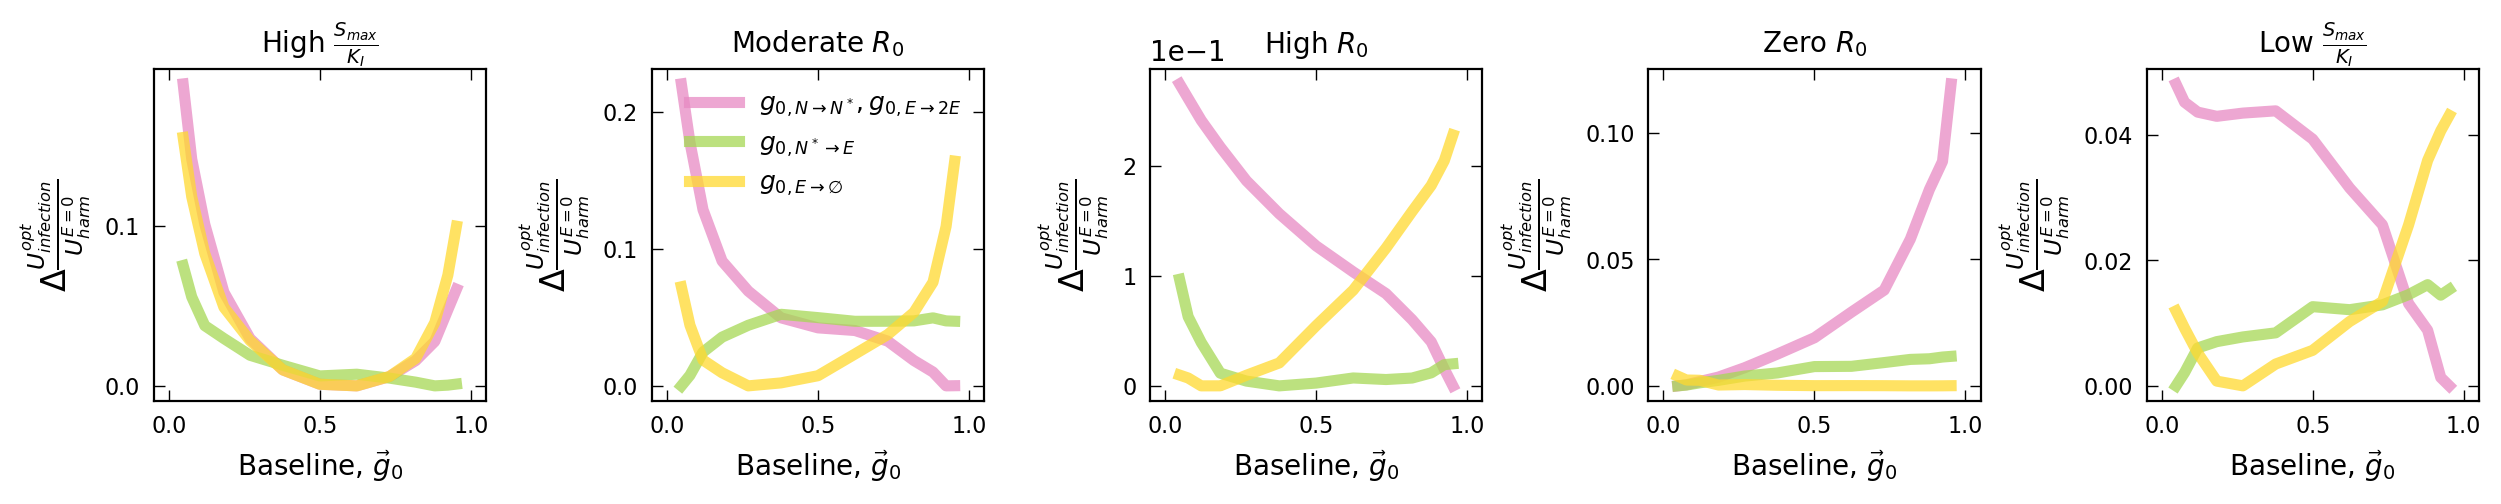

In [142]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on Infection
    for i, var in enumerate(opt_vars[3:]):
        axs.flat[k].plot(g.loc[(g.ablate_index == 3 + i),  [var]].values,
             g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values - np.amin(g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values),
             color = cmap_colors[3 + i], 
                         label = opt_vars_labels[3 + i],
                            **kwargs)

        # axs.flat[k].scatter(g.loc[(g.ablate_index == 3 + i),  [var]].values,
        #                     g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values  - np.amin(g.loc[(g.ablate_index == 3 + i), [perf_vars[perf]]].values),
        #                     label = opt_vars_labels[3 + i],
        #                     color = cmap_colors[3 + i])

    #axs.flat[k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[1].legend(fontsize=9, framealpha=0, ncol = 1)
axs.flat[2].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_xlim(-0.05, 1.05)
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel(r'$\Delta \frac{U_{infection}^{opt}}{U_{harm}^{E = 0}}$', fontsize = 12)
    ax.set_xlabel(r"Baseline, $\vec g_0$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/fig4_'+comment+'-pareto-prot_ablate_baseline'+'.pdf', dpi=300, bbox_inches="tight")

Suggests that antigen and infection harm detection are fingible (once a response has been inititated).

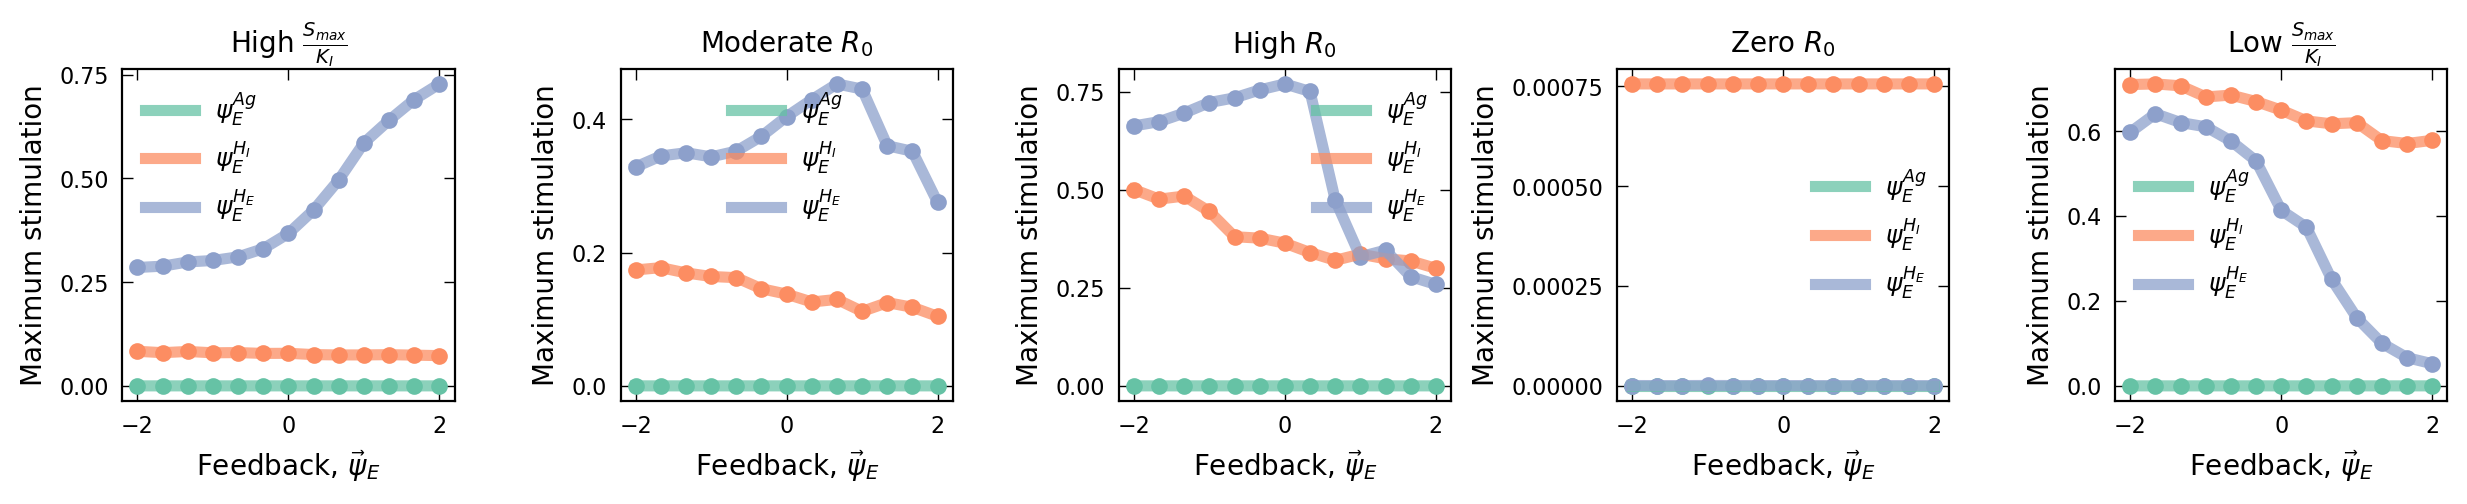

In [32]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    # (a) Effect of single parameter ablation on Infection
    normalize = np.amax(avg_cluster_data.loc[(avg_cluster_data.phase_cluster == k), stim])
    for i, var in enumerate(opt_vars):
        if i <= 2:
            axs[k].plot(g.loc[(g.ablate_index == i),  [var]].values,
                 g.loc[(g.ablate_index == i), [stim_vars[i]]].values/normalize,
                 color = cmap_colors[i], 
                 label = opt_vars_labels[i],
                                **kwargs)

            axs[k].scatter(g.loc[(g.ablate_index == i),  [var]].values,
                 g.loc[(g.ablate_index == i), [stim_vars[i]]].values/normalize,
                 color = cmap_colors[i])

    axs[k].set_title(phase_cluster_labels[k], fontsize = 10.0)

for ax in axs.flat:
    ax.legend(fontsize=9, framealpha=0)
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Maximum stimulation", fontsize = 10)
    ax.set_xlabel(r"Feedback, $\vec\psi_E$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-prot_stim_ablate'+'.pdf', dpi=150, bbox_inches="tight")

Figure above shows sensitive control with the anti-inflammatory signal is required to achieve high levels of Harm. Also, non-monotonic dependence on the activation pathway is observed.

The region of low sensitivity to the anti-inflammatory signal corresponds to biologically observed designs. In particular, it can be seen to drive the optima of the other design variables. Can I show this with correlations? What do we get out of looking at the baseline designs?

KeyboardInterrupt: 

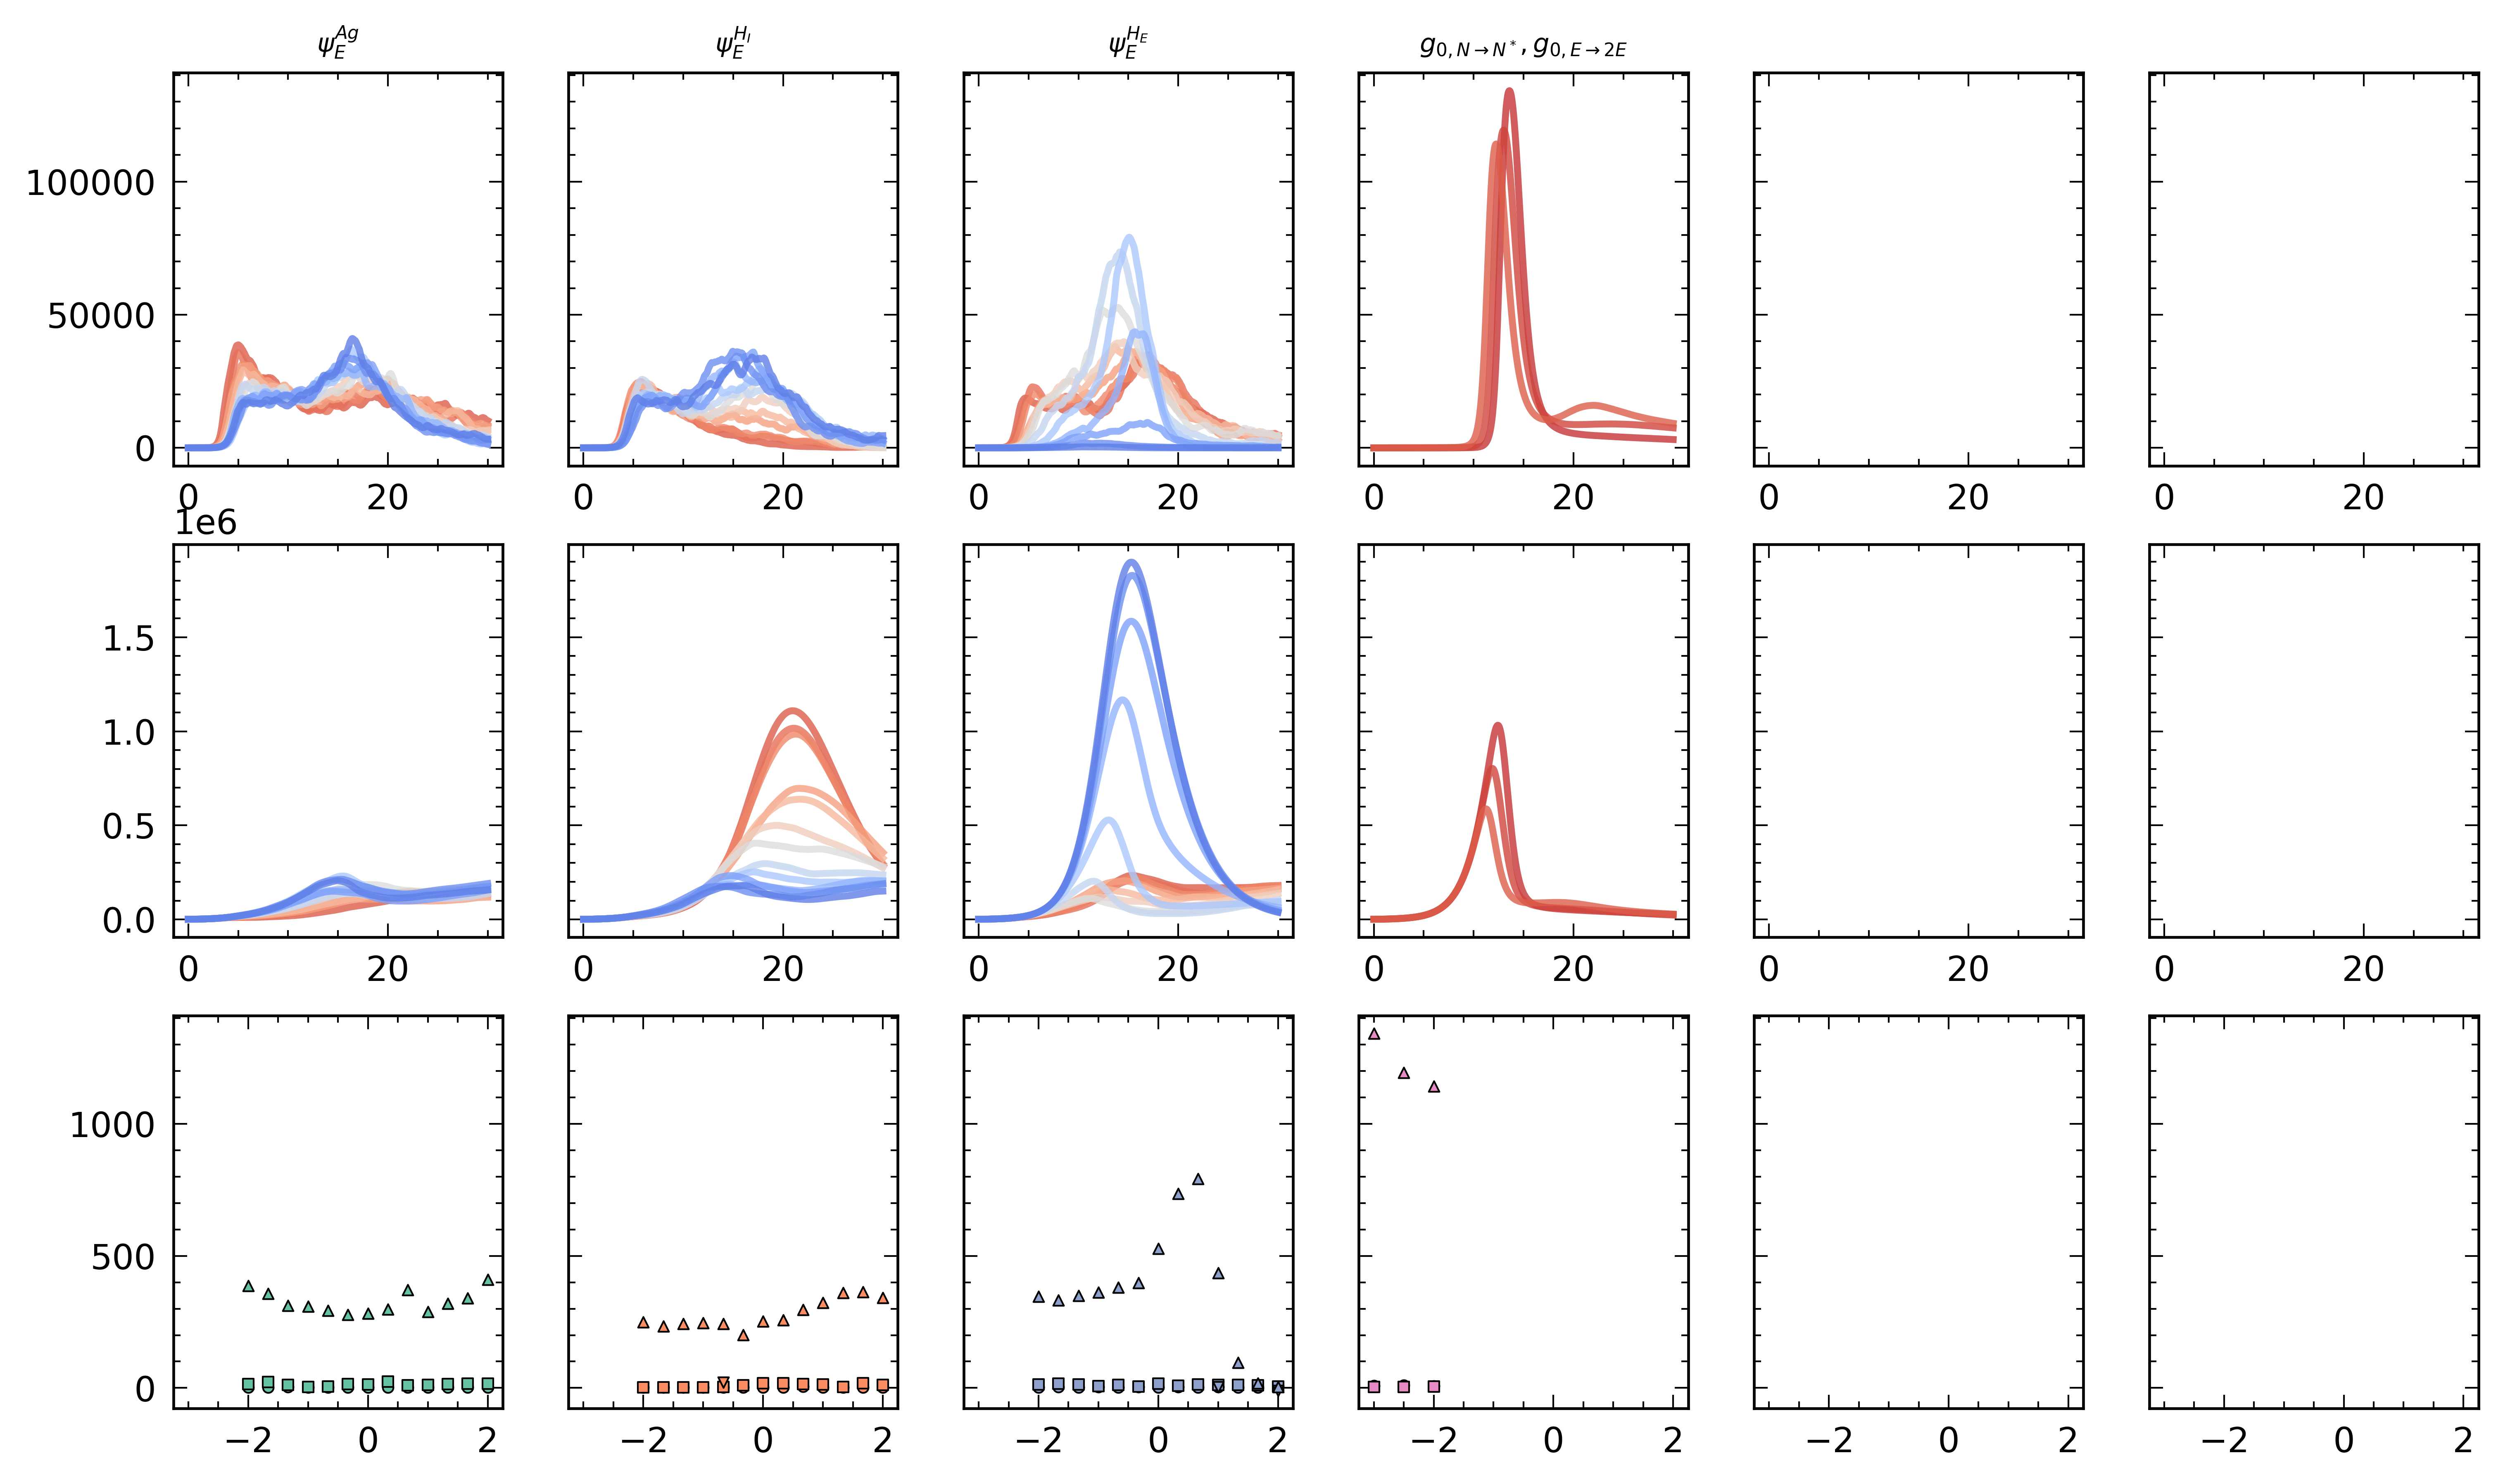

In [145]:
# # Plot select infection responses
# fig, axs = plt.subplots(3,len(opt_vars), dpi = 300, sharex = 'row', sharey = 'row', figsize=(2*len(opt_vars), 7))
# repeat = 1
# select_cluster_data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.phase_cluster == 1)].reset_index()
# # v = select_cluster_data.loc[select_cluster_data[['peff_scaled_total_harm']].idxmax(), vir_vars].values.ravel()
# infection_count = len(select_cluster_data)
# ps = select_cluster_data[opt_vars[0:3] + reg_bl + ['ablate_index']].values
# store_Es = []
# store_Is = []

# # Loop and do 
# for k, p in enumerate(ps):
#     # if (k % n_steps) % 4 == 0:
#     # Vary pareto designs
#     index = int(p[-1])
#     dyn = 0

#     for v in select_cluster_data[vir_vars].values:
#         data_dict = lin_stoch_sim(N_0 = v[4],
#                                   I_0 = v[6],
#                                   b_I = v[2], 
#                                   K_I = v[1],
#                                   d_I = v[0],
#                                   K_H = v[3],
#                                   NE_regulation = [p[0], p[1], p[2], p[4]],
#                                   EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
#                                   activation_regulation = [p[0], p[1], p[2], p[3]],
#                                   contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
#                                   infection_model = 'acute',
#                                   reg_model = 'mwc_like',
#                                   out_data = "full",
#                                   memory_death = False,
#                                   duration = 1.0*sim_duration,
#                                   steps = 1*sim_steps)
        
#         dyn += data_dict["cell_time_series"]
#         ts = data_dict["time"]
#         sim_summary = data_dict["summary_stats"]
    
#     S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0]/infection_count, dyn[:,1]/infection_count, dyn[:,2]/infection_count, dyn[:, 3]/infection_count, dyn[:,4]/infection_count, dyn[:,5]/infection_count, dyn[:,6]/infection_count, dyn[:,7]/infection_count, dyn[:,8]/infection_count, dyn[:,9]/infection_count

#     # Plot cell dynamics
#     axs[0, index].plot(ts, E, linewidth=2.0, color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8)
#     axs[1, index].plot(ts, I, linewidth=2.0, color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8)
#     axs[2, index].scatter(p[index], sim_summary[7], color = cmap_colors[index], linewidths = 0.5,
#                           marker = reg_markers[0], s = 9.5, ec = 'black', label = 'Resp. start' if k == 0 else '') #Effector start time
#     axs[2, index].scatter(p[index], sim_summary[6] - sim_summary[7], color = cmap_colors[index], linewidths = 0.5,
#                           marker = reg_markers[1], ec = 'black', s = 9.5, label = 'Resp. expand' if k == 0 else '') # Effector peak time
#     axs[2, index].scatter(p[index], (sim_summary[10] - sim_summary[6]) if (E[-1] < N_0) else np.nan, color = cmap_colors[index], linewidths = 0.5,
#                           marker = reg_markers[2], ec = 'black', s = 9.5, label = 'Resp. end' if k == 0 else '') # Effector end time
#     axs[2, index].scatter(p[index], np.amax(E)/v[4], color = cmap_colors[index], linewidths = 0.5,
#                           marker = reg_markers[3], ec = 'black', s = 9.5, label = 'Resp. peak' if k == 0 else '') # Effector peak magnitude
    
#     axs[0, index].set_title(opt_vars_labels[index], fontsize = 7.5)
#     if index == 2:
#         store_Es.append(E)
#         store_Is.append(I)

# axs[2, 0].legend(bbox_to_anchor=(1.0, 1.55), fontsize=5.5, framealpha=0, ncol = 1)

# for j, ax in enumerate(axs.flat):
#     ax.set_box_aspect(1)
#     if j // len(opt_vars) == 0:
#         ax.set_ylabel(r'T cells, $E$', fontsize = 8.5)
#         ax.set_xlabel(r"Time [day]", fontsize = 8.5)
#         ax.semilogy()
#         #ax.semilogx()
#         ax.set_ylim(1,)
#     elif j // len(opt_vars) == 1:
#         ax.set_ylabel(r'Infected cells, $I$', fontsize = 8.5)
#         ax.set_xlabel(r"Time [day]", fontsize = 8.5)
#         ax.semilogy()
#         #ax.semilogx()
#         ax.set_ylim(1,)
#     elif j // len(opt_vars) == 2:
#         ax.set_ylabel(r'Memory cells, $eM$', fontsize = 8.5)
#         ax.set_xlabel("Time as\n effector [day]", fontsize = 8.5)
#         #ax.semilogx()
#         ax.semilogy()
#         ax.set_ylim(1,)
#     else:
#         ax.set_xlabel(opt_vars_labels[j % len(opt_vars)], fontsize = 8.5)
#         ax.locator_params(axis='x', nbins=4)
#         ax.set_ylabel("Effector dynamics", fontsize = 8.5)
#         ax.set_yscale('symlog')

#     ax.minorticks_off()
#     ax.tick_params(axis='both', which='major', labelsize=5.5)
#     ax.xaxis.set_tick_params(labelbottom=True)
#     ax.yaxis.set_tick_params(labelleft=True)

# fig.subplots_adjust(wspace=.55, hspace=0.25)

# plt.savefig('_figs/figSI_'+comment+'-pareto-design-ablate_prot-eff-dynamics'+'.pdf', dpi=300, bbox_inches="tight")

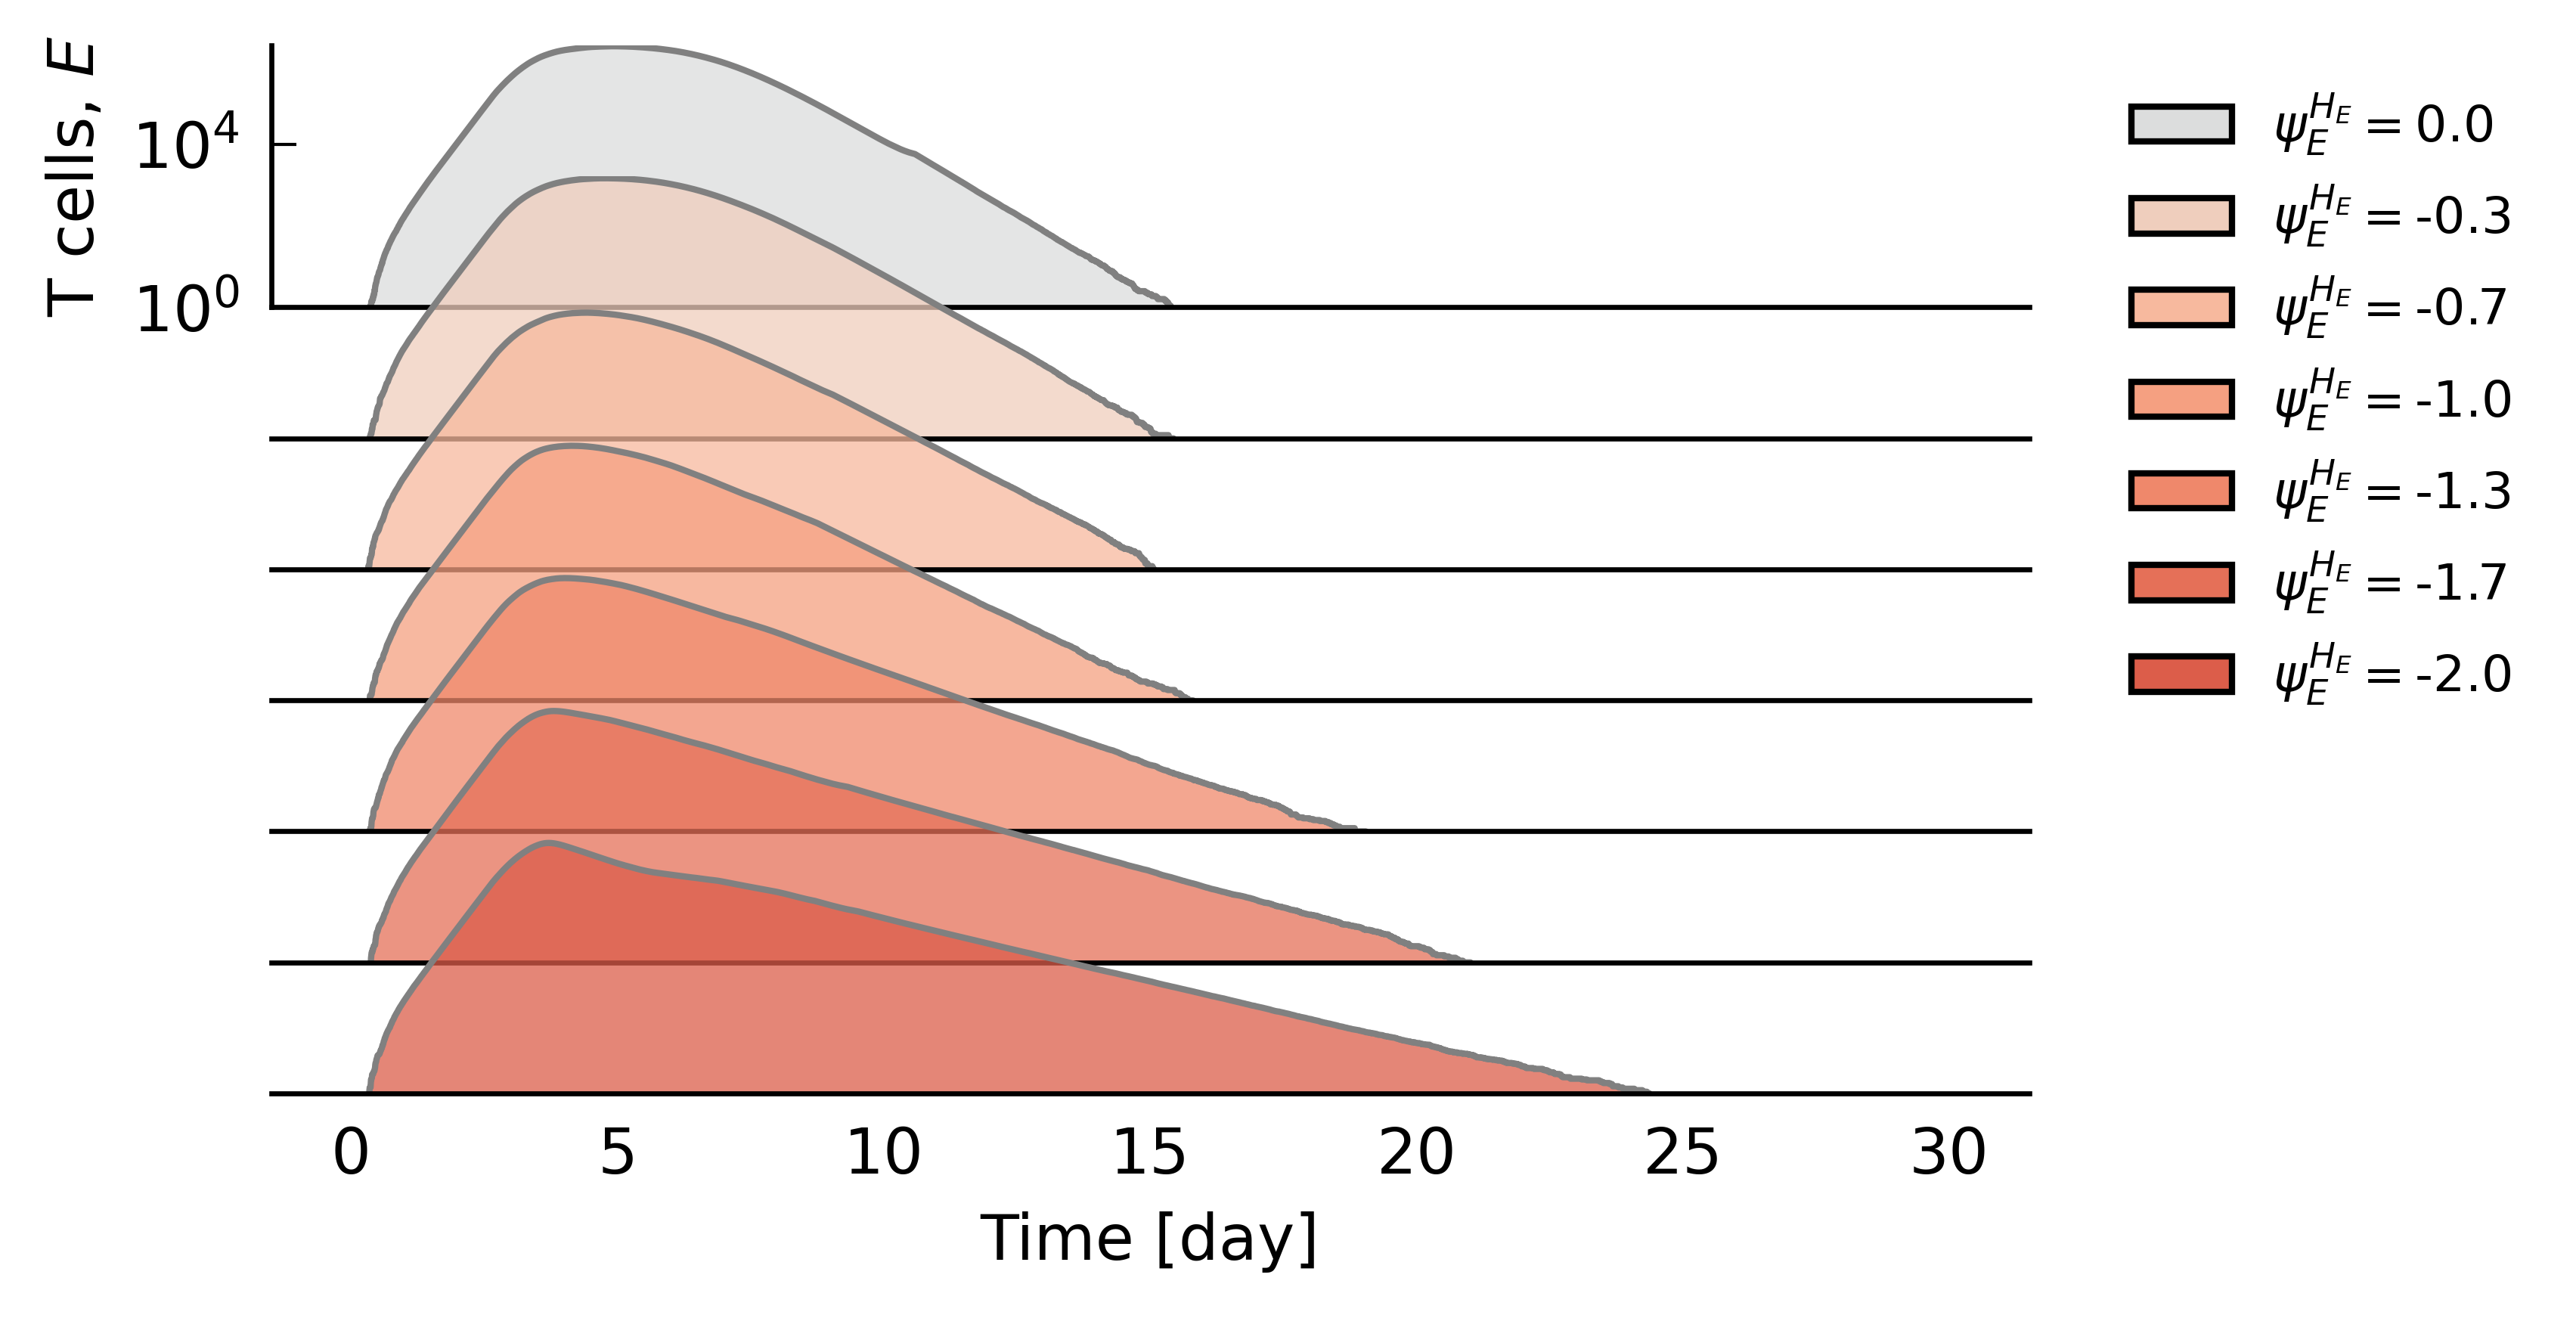

In [34]:
# xs = ts

# ps_HE = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.phase_cluster == 1)*(cluster_ablate_grid_opt.ablate_index == 2)*(cluster_ablate_grid_opt[opt_vars[2]] <= 0)][opt_vars[2]].tolist()[::-1]
# #ps_HE = [p for k, p in enumerate(cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.ablate_index == 2)][opt_vars].values[:,2])  if (k % 4 == 0)][::-1]
# ys = store_Es[:len(ps_HE)][::-1]
# zs = store_Is[:len(ps_HE)][::-1]

# labels = [r"$\psi_E^{H_E} = $" + str(np.round(p, 1)) for p in ps_HE]

# # Plotting code.
# ncols = 1
# nrows = len(ys)

# fig, axes = plt.subplots(
#     ncols=ncols, nrows=nrows, sharex=True, sharey=True, dpi=300,
#     figsize=(5, 3), subplot_kw={"facecolor": (0, 0, 0, 0), "frameon": True},
#     # Control how much axes overlap onto one another.
#     gridspec_kw={"hspace": -0.5}, 
# )

# legend_handles = []

# for idx, (y, ax) in enumerate(zip(ys, axes)):
#     color = plt.cm.coolwarm_r(1/(1 + np.exp(-ps_HE[idx]))) #plt.colormaps["coolwarm"](idx / nrows)

#     # Add black line to top of distribution.
#     ax.plot(xs, y, color='grey', linewidth=1.0)
#     # ax.plot(xs, zs[idx], color='k', linewidth=2.0, label = r"Infected cells, $I$" if idx == 0 else '')
#     ax.set_ylim(1,None)
#     ax.semilogy()
#     #ax.semilogx()

#     # Add black line to bottom of distribution.
#     # Change min_vals to what it should be. E.g., log scale should be min_vals = 1
#     min_vals = np.zeros_like(xs)
#     #ax.plot(xs, min_vals, color='k', linewidth=1)

#     # Create fill distributions. Alpha 
#     ax.fill_between(
#         xs, y, alpha=0.75, color=color, label=labels[idx],
#         linewidth=0
#     )
#     ax.tick_params(
#         right=False, top=False, left=False, bottom=False, which="both",
#         # Turn off y-axis labels.
#         labelleft=False
#     )
#     ax.spines.top.set_visible(False)
#     ax.spines.left.set_visible(False)
#     ax.spines.right.set_visible(False)
#     ax.spines.bottom.set_visible(True)

#     patch_for_legend = plt.matplotlib.patches.Patch(
#         facecolor=color, edgecolor='k', label=labels[idx]
#     )
#     legend_handles.append(patch_for_legend)

# axes[0].tick_params(bottom=True)
# axes[0].spines.bottom.set_visible(True)
# axes[0].tick_params(
#     right=False, top=False, left=True, bottom=False, which="both",
#     # Turn off y-axis labels.
#     labelleft=True
# )
# axes[0].spines.left.set_visible(True)
# axes[-1].set_xlabel("Time [day]", fontsize = 10)
# axes[0].set_ylabel('T cells, '+ r'$E$', fontsize = 10)

# axes[0].legend(
#     handles=legend_handles, framealpha=0,
#     # Adjust location of legend.
#     bbox_to_anchor=(1.3, 1.0),
#     fontsize=8
# )

# #plt.show()

# plt.savefig('_figs/figSI_'+comment+'-pareto-design-ablate_prot-eff-dynamics-splines'+'.pdf', dpi=300, bbox_inches="tight")

In [37]:
from optimize_nets import *

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

pnts = 9
vary_l0s = np.array(list(itertools.product(np.linspace(-L0_max, L0_max, pnts).tolist(),
                                          np.linspace(-L0_max, L0_max, pnts).tolist(),
                                          np.linspace(-L0_max, L0_max, pnts).tolist())))

input_regs = np.array([-0*vary_l0s[:,0], -0*vary_l0s[:,1], -0*vary_l0s[:,2], vary_l0s[:,0], # Na
          -0*vary_l0s[:,0], -0*vary_l0s[:,1], -0*vary_l0s[:,2], vary_l0s[:,1], # NE
          -0*vary_l0s[:,0], -0*vary_l0s[:,1], -0*vary_l0s[:,2], -L0_max**4 -0*vary_l0s[:,1], # EM
          -0*vary_l0s[:,0], -0*vary_l0s[:,1], -0*vary_l0s[:,2], vary_l0s[:,2]]).T  # Edie

run(batch = [-1], outdir=d, inf_sample = cluster_input.loc[['d_I', 'K_I', 'b_I', 'K_H', 'N_0','I_0']], 
    comment="sim_vary_l0s", runs = 5, infection_model = 'acute_ag', default_reg = input_regs, 
    num_cpu = num_cpu, run_time = 10)

d_file = d + '/sim_batch_-1-5-acute_ag-sim_vary_l0s.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
vary_l0s_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names]).merge(cluster_input[['K_I', 'b_I', 'K_H', 'N_0','I_0'] + ['phase_cluster']], how = 'left', on = ['K_I', 'b_I', 'K_H', 'N_0','I_0'])

vary_l0s_data.loc[:, 'R_0'] = vary_l0s_data['S_0']*vary_l0s_data['b_I']/vary_l0s_data['d_I'] - 1
vary_l0s_data.loc[:,'exp_rate'] = np.log(np.maximum(vary_l0s_data['max_pE'], max_Na)/max_Na)/np.maximum(t_cycle, vary_l0s_data['T_pE_max'] - vary_l0s_data['T_pE_start'])
vary_l0s_data.loc[:,'end_rate'] = -np.log(np.maximum(vary_l0s_data['N_0'], vary_l0s_data['E_end'])/np.maximum(vary_l0s_data['N_0'], vary_l0s_data['max_pE']))/np.maximum(t_cycle, vary_l0s_data['T_pE_end'] - vary_l0s_data['T_pE_max'])
vary_l0s_data.loc[:,'max_expE'] = vary_l0s_data['max_pE']/vary_l0s_data['N_0']
vary_l0s_data.loc[:,opt_vars[0:3]] = np.round(vary_l0s_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values, 3)
vary_l0s_data.loc[:,opt_vars[3:]] = np.round(1/(1 + np.exp(-vary_l0s_data[reg_bl].values)), 3)
vary_l0s_data.loc[:,"harm_pI_noprotection"] = vary_l0s_data.apply(lambda row: np.mean(cluster_input.harm_pI_noprotection.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))]), axis=1)

vary_l0s_data.loc[:,"peff_infection"] = 1.0 - vary_l0s_data['harm_pI']/S_0
vary_l0s_data.loc[:,"peff_toxicity"] = vary_l0s_data['harm_pS']/S_0
vary_l0s_data.loc[:,"peff_scaled_total_harm"] = (vary_l0s_data['peff_infection'] - vary_l0s_data['peff_toxicity'])/vary_l0s_data['harm_pI_noprotection']

vary_eff_dyn_design = vary_l0s_data.groupby(opt_vars, as_index = False, sort = False).mean()


# with pd.option_context('display.max_columns', None):
#     display(prot_eff_dyn_design)

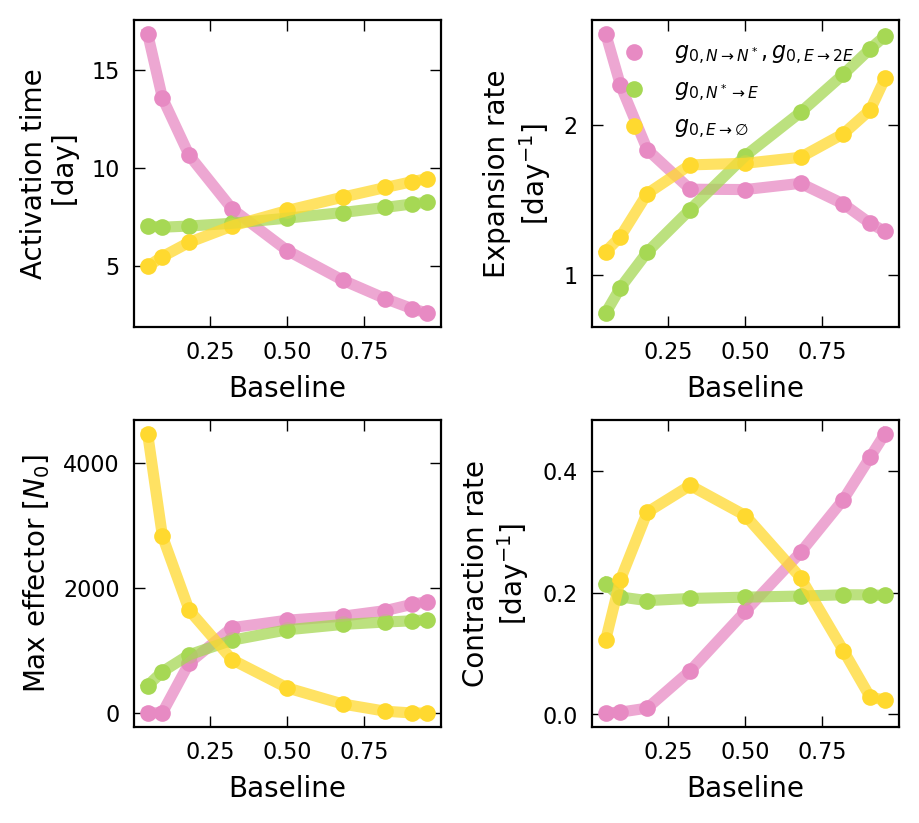

In [38]:
# Plot dependency of effector dynamics on design
eff_dyn_vars = ['T_pE_start', 'exp_rate', 'max_expE', 'end_rate']#, 'E_end', 'peff_infection'] #'exp_rate', , 'sel_ratio'
eff_dyn_labels = ['Activation time\n [day]', 'Expansion rate\n'+r'[$\text{day}^{-1}$]', 'Max effector '+ r'[$N_0$]',
                  'Contraction rate\n'+r'[$\text{day}^{-1}$]'] #,'Final effector'+ r'[$N_0$]', perf_labels[1]+r' [$S_{max}$]'] # 'Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', , 'Response avidity'

# Make trade-off figure
fig, axs = plt.subplots(2, 2,figsize=(4.5, 4), sharex='row', sharey=False, layout='constrained')

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

for k, (eff_var, ax) in enumerate(zip(eff_dyn_vars, axs.flat)):

    # (a) Effect of single parameter ablation on Harm
    for i, var in enumerate(opt_vars[3:]):
        plot_data = vary_eff_dyn_design.groupby([var], as_index = False).mean()
        
        ax.plot(np.abs(plot_data[var].values),
                plot_data[eff_var].values/(1 if k != 4 else plot_data['N_0'].values),
                color = cmap_colors[3 + i], 
                            **kwargs)

        ax.scatter(np.abs(plot_data[var].values),
                   plot_data[eff_var].values/(1 if k != 4 else plot_data['N_0'].values),
                   label = opt_vars_labels[3 + i], # (r"$-$" if i == 2 else '')+
                   color = cmap_colors[3 + i])
        
    if k == 1:
        ax.legend(fontsize=8, framealpha=0, ncol = 1) # bbox_to_anchor=(1.0, 1), 
    
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    ax.locator_params(axis='x', nbins=4)
    if 'exp.' not in eff_dyn_labels[k]:
        ax.locator_params(axis='y', nbins=4)
    else:
        ax.semilogy()

    ax.minorticks_off()
    #ax.set_ylim(0, None)
    ax.set_ylabel(eff_dyn_labels[k], fontsize = 10)
    ax.set_xlabel("Baseline", fontsize = 10)
    
#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/'+comment+'-design-vary_prot-eff-dynamics-simple'+'.pdf', dpi=300, bbox_inches="tight")

The strong negative effect of down-regulation with the anti-inflammatory signal is a strong argument for why it may be in the regime of weak regulation. In some ways the anti-inflammatory signal can be auto-regulatory.

Also, plot performance of optimal acute response designs while varying anti-inflammatory sensitivity, along with the performance of these same designs in other scenarios. Probably want to normalize Harm by Infection.

A strong antigen response causes a lot of toxicity when applied to a weak antigen. But the response can be adjusted.

Optimal designs switch between modes of Infection and containment of the infection. How can I show this more suscinctly? Maybe focus on the time it takes for the infection to clear? Maybe sample design space and do clustering/low dimensional embedding of the 4 effector dynamics variables and then look within those clusters?

Maybe only relevant when we focus in on the anti-inflammatory feedback and the naive to effector pathway for Ag. dominant infections. This figure is about trade-offs.

#### Application to a model of autoimmune triggers

In [40]:
# Define variables and dataframes
zeroR0_plots = [vir_vars[6], vir_vars[4]]
zeroR0_plot_labels = ["Perturbation [$S_{max}$]", r"Dosage [$S_{max}$]"]

In [41]:
# from optimize_nets import *
# num_pnts = 11
# runs = 10
# sample = np.array(np.meshgrid(np.array([0.5]), # vary d_I
#                                    S_0*np.array([0.1]), # vary K_I
#                                    b_I*np.array([0.0]), # vary b_I
#                                    K_H*np.array([1.0]), # vary K_H
#                                    N_0*np.logspace(-2.0, 2.0, num_pnts), # vary N_0
#                                    I_min*np.logspace(-1.0, 2.0, num_pnts)# vary I_0
#                                            )).T.reshape(-1,6)

# d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

# h = 1e-1
# arr = np.arange(0, len(acute_pareto_reg))
# ps = np.vstack([[acute_pareto_reg - h*(arr == j), acute_pareto_reg, acute_pareto_reg + h*(arr == j)] for j, a in enumerate(arr)])
# zeroR0_psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
#           ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
#           -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**3 -0*ps[:,4], # EM
#           -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# # run simulations for extreme scenarios
# run(batch = [-1], outdir=d, inf_sample = sample, 
#     comment="zeroR0_acute_comp_sim", runs = runs, infection_model = '', 
#     default_reg = zeroR0_psis,
#     num_cpu = num_cpu)

In [42]:
# d_file = d + '/sim_batch_-1-10--zeroR0_acute_comp_sim.pkl'
# with open(d_file, 'rb') as f:   
#     data_dict = pickle.load(f)

# parameters = data_dict["parameters"]
# sim_summary = data_dict["summary_stats"]
# var_names = np.concatenate((param_names_for_df, stat_names_for_df))
# zeroR0_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).groupby(zeroR0_plots + reg, as_index=False).mean()

# # compute infection harm without T cell response
# zeroR0_acute_comp_df.loc[:,opt_vars[0:3]] = zeroR0_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
# zeroR0_acute_comp_df.loc[:,"harm_pI_noprotection"] = zeroR0_acute_comp_df['I_0'].to_numpy()/S_0
# zeroR0_acute_comp_df.loc[:,"peff_infection"] = (zeroR0_acute_comp_df['I_0'].to_numpy() - zeroR0_acute_comp_df['harm_pI'].to_numpy())/S_0
# zeroR0_acute_comp_df.loc[:,"peff_toxicity"] = zeroR0_acute_comp_df['harm_pS'].to_numpy()/S_0
# zeroR0_acute_comp_df.loc[:,"peff_protection"] = (zeroR0_acute_comp_df['peff_infection'] - zeroR0_acute_comp_df['peff_toxicity'])
# zeroR0_acute_comp_df.loc[:,"peff_scaled_total_harm"] = zeroR0_acute_comp_df['peff_protection']/zeroR0_acute_comp_df['harm_pI_noprotection']

In [43]:
# # Find optimal dosage for each Affinity
# data = zeroR0_acute_comp_df.loc[np.sum(np.abs(zeroR0_acute_comp_df[opt_vars[0:3] + reg_bl] - acute_pareto_reg), axis = 1) == 0]
# opt_N0 = data.loc[data.groupby('I_0')['peff_scaled_total_harm'].idxmax()].copy()
# data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.median(data['N_0'].values))
# fixed_N0 = data.loc[data.groupby('I_0')['N_0_match'].idxmin()].copy() #np.amax(data['N_0'])

# # Compute effect of perturbation in the design
# gradients = []
# for k, (a,b) in enumerate(fixed_N0[['I_0', 'N_0']].values):
#     input = zeroR0_acute_comp_df.loc[(zeroR0_acute_comp_df.I_0 == a)*(zeroR0_acute_comp_df.N_0 == b)].copy()
#     input.loc[:,'dummy'] = np.sum(np.abs(input.copy()[opt_vars[0:3] + reg_bl].values - acute_pareto_reg), axis = 1)
#     out = np.zeros(len(opt_vars[0:3] + reg_bl))
#     for i, var in enumerate(opt_vars[0:3] + reg_bl):
#         f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_scaled_total_harm.values
#         grad = np.gradient(f, h)
#         out[i] += grad[1]

#     gradients.append(out)

# gradients_data = np.vstack(gradients)

In [44]:
# fig, axs = plt.subplots(3, 1, figsize=(2, 7), sharex=False, sharey=False)

# size = 600/num_pnts
# data = zeroR0_acute_comp_df.loc[np.sum(np.abs(zeroR0_acute_comp_df[opt_vars[0:3] + reg_bl] - acute_pareto_reg), axis = 1) == 0]
# im = axs[0].scatter(data['I_0'].values/data['S_0'].values,
#                  data['N_0'].values/data['S_0'].values, #/data['S_0'].values,
#                  marker = 's', s = size,
#                  c = data['peff_scaled_total_harm'].values, 
#                  cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
#                  norm = mpl.colors.SymLogNorm(1.0))

# axs[0].semilogy()
# axs[0].set_ylabel(zeroR0_plot_labels[1], fontsize = 10)

# axs[0].scatter(opt_N0['I_0'].values/opt_N0['S_0'].values,
#          opt_N0['N_0'].values/opt_N0['S_0'].values, #/opt_N0['S_0'].values,
#          color = 'yellow', marker = '.')

# for j,perf in enumerate(perf_vars[0:3]):
#     axs[1].plot(opt_N0['I_0'].values/opt_N0['S_0'].values,
#              opt_N0[perf].values/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
#              color = ['green', 'black', 'red'][j],
#                **kwargs)

#     axs[1].scatter(opt_N0['I_0'].values/opt_N0['S_0'].values,
#          opt_N0[perf].values/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
#          color = ['green', 'black', 'red'][j], label = ["Harm",perf_labels[1],perf_labels[2]][j])

# axs[1].set_ylabel("Performance", fontsize = 10)
# axs[1].set_yscale('symlog')

# #axs[1].locator_params(axis='y', nbins=4)
# axs[1].legend(bbox_to_anchor=(1.0, 1),fontsize = 9)

# for i, var in enumerate(opt_vars_labels):
#     axs[2].plot(opt_N0['I_0'].values/opt_N0['S_0'].values,
#                 gradients_data[:,i],
#                 color = cmap_colors[i], 
#                 #linestyle = linestyles[i],
#                 **kwargs)

#     axs[2].scatter(opt_N0['I_0'].values/opt_N0['S_0'].values,
#                 gradients_data[:,i],
#                    label = (opt_vars_labels[0:3] + reg_bl_label)[i],
#                 color = cmap_colors[i])

# axs[2].set_ylabel(r"$\nabla$"+" Scaled Harm", fontsize = 10)
# axs[2].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=9)
# axs[2].set_yscale('symlog')
    

# for ax in axs.flat:
#     ax.semilogx()
#     ax.set_box_aspect(1)
#     ax.minorticks_off()
#     ax.tick_params(axis='both', which='major', labelsize=9)
#     ax.set_xlabel(zeroR0_plot_labels[0], fontsize = 10)

# z_label = "Scaled Harm"
# cb = fig.colorbar(im, ax=axs[0], location='top', shrink = 0.7, pad = 0.025)
# cb.set_label(z_label, fontsize = 10)
# cb.ax.tick_params(labelsize=8)

# fig.subplots_adjust(wspace=.0, hspace=0.5)

# plt.savefig('_figs/'+comment+'-reg-_compare_acute_prot_w_zeroR0_pareto_design'+'.pdf', dpi=300, bbox_inches="tight")

#### Application to a model of a fast-growing tumor

In [74]:
# Define variables and dataframes
cancer_plots = [vir_vars[1], vir_vars[0], vir_vars[4]]
cancer_plot_labels = ["Affinity", r"Dosage [$S_{max}$]"]

cancers_labels = ['Lower ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', lower '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', intermediate '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+', higher '+cancer_plot_labels[1]]

cancers_labels_indent = ['Lower ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Lower ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Intermediate ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n lower '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n intermediate '+cancer_plot_labels[1],
                      'Higher ' + cancer_plot_labels[0]+',\n higher '+cancer_plot_labels[1]]

In [46]:
def choose_continous_color(x, color):
    if color == 0:
        out = plt.cm.Greys(x)
    elif color == 1:
        out = plt.cm.Blues(x)
    elif color == 2:
        out = plt.cm.Reds(x)

    return out

There a sort of goldilocks effect where the designs for cancer Harm are suboptimal for acute response but the worst designs those of intermediate Affinity.

##### Compute tumour Harm of Ag. dominant pareto Harm

In [55]:
from optimize_nets import *
num_pnts = 15
runs = 5
sample = np.array(np.meshgrid(d_S*np.array([1.0]), # vary d_I
                                   S_0*np.logspace(-3.0, 0.0, num_pnts), # vary K_I
                                   b_C*np.array([1.0]), # vary b_I
                                   K_H*np.array([1.0]), # vary K_H
                                   N_0*np.logspace(-2.0, 2.0, num_pnts), # vary N_0
                                   S_0*np.array([0.1]) # vary I_0
                                           )).T.reshape(-1,6)

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

h = 1e-1
arr = np.arange(0, len(acute_pareto_reg))
ps = np.vstack([[acute_pareto_reg - h*(arr == j), acute_pareto_reg, acute_pareto_reg + h*(arr == j)] for j, a in enumerate(arr)])
cancer_psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
          ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
          -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**3 -0*ps[:,4], # EM
          -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample, 
    comment="cancer_acute_comp_sim", runs = runs, infection_model = '', 
    default_reg = cancer_psis,
    num_cpu = num_cpu)

Running 20250 simulations in batch #-1
Saved sim_batch_-1-5--cancer_acute_comp_sim.pkl
0.23022940973440806 hrs


In [56]:
d_file = d + '/sim_batch_-1-5--cancer_acute_comp_sim.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
cancer_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).groupby(cancer_plots + reg, as_index=False).mean()

# compute infection harm without T cell response
no_eff_data = lin_stoch_sim(N_0 = 0, I_0 = sample[0][5], K_I = K_I, d_I = sample[0][0], b_I = sample[0][2],
                               infection_model = "cancer")
no_eff_stats = no_eff_data["summary_stats"]

cancer_acute_comp_df.loc[:,opt_vars[0:3]] = cancer_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
cancer_acute_comp_df.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/S_0
cancer_acute_comp_df.loc[:,"peff_infection"] = cancer_acute_comp_df['harm_pI'].to_numpy()/S_0
cancer_acute_comp_df.loc[:,"peff_toxicity"] = cancer_acute_comp_df['harm_pS'].to_numpy()/S_0
cancer_acute_comp_df.loc[:,"peff_total_harm"] = (cancer_acute_comp_df['peff_infection'] + cancer_acute_comp_df['peff_toxicity'])
cancer_acute_comp_df.loc[:,"peff_scaled_total_harm"] = cancer_acute_comp_df['peff_total_harm']/cancer_acute_comp_df['harm_pI_noprotection']

In [66]:
# Find optimal dosage for each Affinity
data = cancer_acute_comp_df.loc[np.sum(np.abs(cancer_acute_comp_df[opt_vars[0:3] + reg_bl] - acute_pareto_reg), axis = 1) == 0]
opt_N0 = data.loc[data.groupby('K_I')['peff_total_harm'].idxmin()].copy()
data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.max(data['N_0'].values))
fixed_N0 = data.loc[data.groupby('K_I')['N_0_match'].idxmin()].copy() #np.amax(data['N_0'])

# Compute effect of perturbation in the design
gradients = []
for k, (a,b) in enumerate(fixed_N0[['K_I', 'N_0']].values):
    input = cancer_acute_comp_df.loc[(cancer_acute_comp_df.K_I == a)*(cancer_acute_comp_df.N_0 == b)].copy()
    input.loc[:,'dummy'] = np.sum(np.abs(input.copy()[opt_vars[0:3] + reg_bl].values - acute_pareto_reg), axis = 1)
    out = np.zeros(len(opt_vars[0:3] + reg_bl))
    for i, var in enumerate(opt_vars[0:3] + reg_bl):
        f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_scaled_total_harm.values
        grad = np.gradient(f, h)
        out[i] += grad[1]

    gradients.append(out)

gradients_data = np.vstack(gradients)

/tmp/ipykernel_7301/3601078353.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.max(data['N_0'].values))


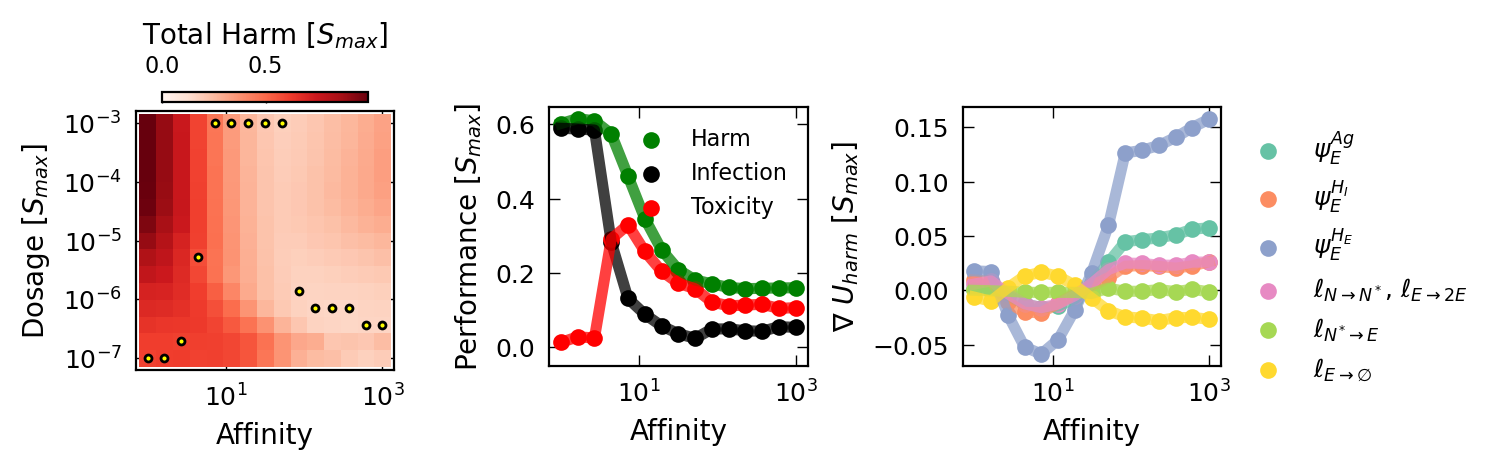

In [76]:
fig, axs = plt.subplots(1, 3, figsize=(7, 2.5), sharex=False, sharey=False) #, layout='constrained')

size = 600/num_pnts
data = cancer_acute_comp_df.loc[np.sum(np.abs(cancer_acute_comp_df[opt_vars[0:3] + reg_bl] - acute_pareto_reg), axis = 1) == 0]
im = axs[0].scatter(data['S_0'].values/data['K_I'].values,
                 data['N_0'].values/data['S_0'].values, #/data['S_0'].values,
                 marker = 's', s = size,
                 c = data['peff_total_harm'].values, 
                 cmap='Reds', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0))

axs[0].semilogy()
axs[0].set_ylabel(cancer_plot_labels[1], fontsize = 10)

axs[0].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
         opt_N0['N_0'].values/opt_N0['S_0'].values, #/opt_N0['S_0'].values,
         color = 'yellow', marker = '.', edgecolors = 'black', zorder = 7)

for j,perf in enumerate(['peff_total_harm'] + perf_vars[1:3]):
    axs[1].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
             opt_N0[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
             color = ['green', 'black', 'red'][j],
               **kwargs)

    axs[1].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
         opt_N0[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
         color = ['green', 'black', 'red'][j], label = ["Harm",perf_labels[1],perf_labels[2]][j])

axs[1].set_ylabel(r"$U_\cdot$ [$S_{max}$]", fontsize = 10)
axs[1].set_ylim(-0.05, None)

axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(loc = 'upper right',fontsize = 8)

for i, var in enumerate(opt_vars_labels):
    axs[2].plot(opt_N0['S_0'].values/opt_N0['K_I'].values,
                gradients_data[:,i],
                color = cmap_colors[i], 
                #linestyle = linestyles[i],
                **kwargs)

    axs[2].scatter(opt_N0['S_0'].values/opt_N0['K_I'].values,
                gradients_data[:,i],
                   label = (opt_vars_labels[0:3] + reg_bl_label)[i],
                color = cmap_colors[i])

axs[2].set_ylabel(r"$\nabla$"+r" $U_{harm}$ [$S_{max}$]", fontsize = 10)
axs[2].legend(bbox_to_anchor=(1.0, 1), ncol = 1, fontsize=9)
#axs[2].set_ylim(-1.1*np.amax(np.abs(gradients_data)), 1.1*np.amax(np.abs(gradients_data)))
    

for ax in axs.flat:
    ax.semilogx()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=9)
    ax.set_xlabel(cancer_plot_labels[0], fontsize = 10)

z_label = r"$U_{harm}$ [$S_{max}$]"
cb = fig.colorbar(im, ax=axs[0], location='top', shrink = 0.8, pad = 0.025)
cb.set_label(z_label, fontsize = 10)
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.6, hspace=0.5)

plt.savefig('_figs/'+comment+'-reg-_compare_acute_prot_w_cancer_pareto_design'+'.pdf', dpi=300, bbox_inches="tight")

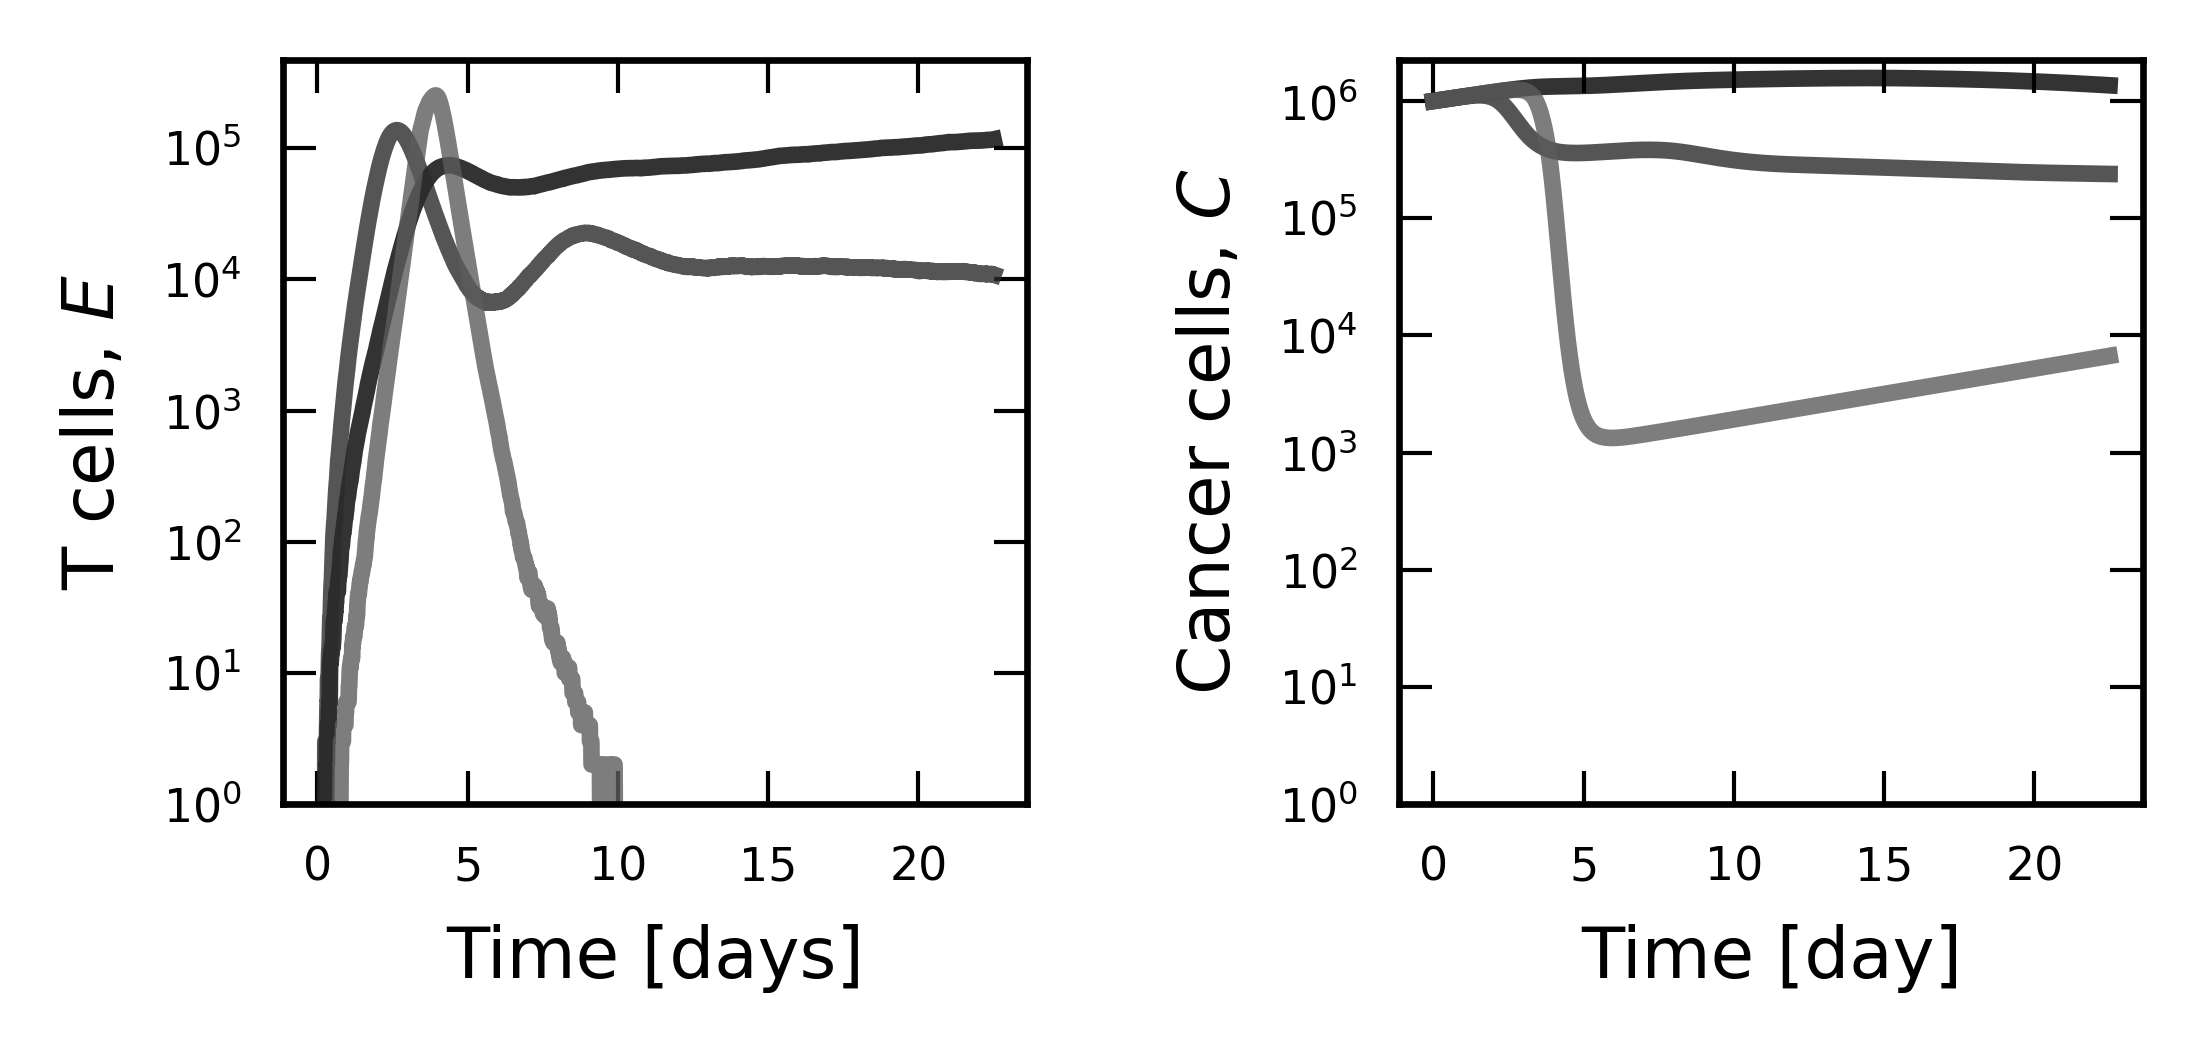

In [51]:
# Plot select infection responses
fig, axs = plt.subplots(1,2, dpi = 300, sharex = False, sharey = False, figsize=(4, 2))

sample = opt_N0[vir_vars].sort_values(by=cancer_plots[0], 
                                      ascending = [False]).values[[0, num_pnts // 2, -1],:]

store_runs = []
# Loop and do 
for k, v in enumerate(sample):

    feedback = p[-1]
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[6],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              K_S = v[5],
                              NE_regulation = [acute_pareto_reg[0], acute_pareto_reg[1], acute_pareto_reg[2], acute_pareto_reg[4]],
                              activation_regulation = [acute_pareto_reg[0], acute_pareto_reg[1], acute_pareto_reg[2], acute_pareto_reg[3]],
                              contraction_regulation = [-acute_pareto_reg[0], -acute_pareto_reg[1], -acute_pareto_reg[2], acute_pareto_reg[5]],
                              infection_model = 'cancer',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False,
                              duration = 0.75*sim_duration,
                              steps = 1.0*sim_steps)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[0].plot(ts, E, linewidth=2.0, color = plt.cm.Greys(np.log(v[1])/np.log((S_0))), alpha = 0.8)
    axs[1].plot(ts, I, linewidth=2.0, color = plt.cm.Greys(np.log(v[1])/np.log((S_0))), alpha = 0.8)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j == 0:
        ax.set_ylabel(r'T cells, $E$', fontsize = 8.5)
        ax.set_xlabel(r"Time [days]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1,)
    elif j == 1:
        ax.set_ylabel(r'Cancer cells, $C$', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1,)
    else:
        ax.set_xlabel("Affinity", fontsize = 8.5)
        #ax.locator_params(axis='x', nbins=4)
        ax.set_ylabel("Effector observable", fontsize = 8.5)
        #ax.set_yscale('symlog')
        # ax.semilogy()
        ax.semilogx()

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-pareto-design-cancer_prot-eff-dynamics'+'.pdf', dpi=300, bbox_inches="tight")

Focusing on anti-inflammatory feedback, the optimal designs for acute response perform best with a treatment of high Affinity and low dosage. What does this look like dynamically?

Fixing a pareto optimal network (with acute design) and varying one of the parameters we find that the biggest impact on performance in the biologically plausible range of inflammatory feedback comes from increasing/decreasing the inflammatory signal and/or the Naive to effector transition baseline. This suggests that if cancer can hide it's inflamatory signals it will be harder to clear.